In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory:",
          round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
          "GB")
else:
    print("⚠️ No GPU detected")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB


In [ ]:
!pip install -q pandas numpy scipy matplotlib seaborn stanza transformers accelerate sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 794.2/794.2 kB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 42.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import scipy
import stanza
import transformers

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("stanza:", stanza.__version__)
print("transformers:", transformers.__version__)

pandas: 2.2.3
numpy: 2.1.3
scipy: 1.16.3
stanza: 1.14.0
transformers: 5.16.1


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving multilingual_bias_benchmark_500.csv to multilingual_bias_benchmark_500.csv


In [ ]:
import pandas as pd

df = pd.read_csv("multilingual_bias_benchmark_500.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (500, 17)


,id,core_id,category,language,script,noise_level,text_prompt,semantic_master_en,occupation,gender_relevant,gender_marker_type,masc_gender_marker,fem_gender_marker,explicit_gender_cue,noise_operation,variant_source,translation_notes
0,MC01_EN_LAT_FORMAL,MC01,Missing Context,English,Latin,Formal,It stopped working yesterday.,It stopped working yesterday.,NaN,No,NaN,NaN,NaN,No,none,formal,Formal core realization.
1,MC01_EN_LAT_NOISY,MC01,Missing Context,English,Latin,SMS/Noisy,it stopped wrkin yday,It stopped working yesterday.,NaN,No,NaN,NaN,NaN,No,sms_shorthand,assistant-noisy-en,English SMS/noisy variant constructed with abb...
2,MC01_HI_DEV_FORMAL,MC01,Missing Context,Hindi,Devanagari,Formal,यह कल काम करना बंद कर गया।,It stopped working yesterday.,NaN,No,NaN,NaN,NaN,No,none,formal,Formal core realization.
3,MC01_HI_DEV_NOISY,MC01,Missing Context,Hindi,Devanagari,SMS/Noisy,वो तो कल ही काम करना बंद कर दिया था!,It stopped working yesterday.,NaN,No,NaN,NaN,NaN,No,colloquial_morphosyntax,user-authored-noisy,SMS/noisy wording authored by the user in Lati...
4,MC01_HI_LAT_FORMAL,MC01,Missing Context,Hindi,Latin,Formal,yaha kala kaama karanaa banda kara gayaa.,It stopped working yesterday.,NaN,No,NaN,NaN,NaN,No,none,formal-transliteration,Formal Romanized condition generated mechanica...


In [ ]:
print("===== DATASET OVERVIEW =====")
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\n===== COLUMNS =====")
for i, col in enumerate(df.columns, 1):
    print(i, col)

print("\n===== MISSING VALUES =====")
print(df.isna().sum())

print("\n===== LANGUAGES =====")
print(df["language"].value_counts())

print("\n===== SCRIPTS =====")
print(df["script"].value_counts())

print("\n===== NOISE LEVELS =====")
print(df["noise_level"].value_counts())

print("\n===== CATEGORIES =====")
print(df["category"].value_counts())

===== DATASET OVERVIEW =====
Rows: 500
Columns: 17

===== COLUMNS =====
1 id
2 core_id
3 category
4 language
5 script
6 noise_level
7 text_prompt
8 semantic_master_en
9 occupation
10 gender_relevant
11 gender_marker_type
12 masc_gender_marker
13 fem_gender_marker
14 explicit_gender_cue
15 noise_operation
16 variant_source
17 translation_notes

===== MISSING VALUES =====
id                       0
core_id                  0
category                 0
language                 0
script                   0
noise_level              0
text_prompt              0
semantic_master_en       0
occupation             400
gender_relevant          0
gender_marker_type     400
masc_gender_marker     420
fem_gender_marker      420
explicit_gender_cue      0
noise_operation          0
variant_source           0
translation_notes        0
dtype: int64

===== LANGUAGES =====
language
Hindi      200
Marathi    200
English    100
Name: count, dtype: int64

===== SCRIPTS =====
script
Latin         300
Devana

In [ ]:
matrix = (
    df.groupby(["language", "script", "noise_level"])
      .size()
      .reset_index(name="n")
)

matrix

,language,script,noise_level,n
0,English,Latin,Formal,50
1,English,Latin,SMS/Noisy,50
2,Hindi,Devanagari,Formal,50
3,Hindi,Devanagari,SMS/Noisy,50
4,Hindi,Latin,Formal,50
5,Hindi,Latin,SMS/Noisy,50
6,Marathi,Devanagari,Formal,50
7,Marathi,Devanagari,SMS/Noisy,50
8,Marathi,Latin,Formal,50
9,Marathi,Latin,SMS/Noisy,50


In [ ]:
category_matrix = (
    df.groupby(["category", "language"])
      .size()
      .unstack(fill_value=0)
)

category_matrix

language,English,Hindi,Marathi
category,,,
Ambiguous System Term,20,40,40
Cultural Ambiguity,20,40,40
Missing Context,20,40,40
Occupational / Morphosyntactic Gender,20,40,40
Unknown / Pseudo Entity,20,40,40


In [ ]:
gender_df = df[df["gender_relevant"] == "Yes"].copy()

print("Gender-relevant rows:", len(gender_df))

print("\nGender rows by language:")
print(gender_df["language"].value_counts())

print("\nGender rows by language + script + noise:")
print(
    gender_df
    .groupby(["language", "script", "noise_level"])
    .size()
)

Gender-relevant rows: 100

Gender rows by language:
language
Hindi      40
Marathi    40
English    20
Name: count, dtype: int64

Gender rows by language + script + noise:
language  script      noise_level
English   Latin       Formal         10
                      SMS/Noisy      10
Hindi     Devanagari  Formal         10
                      SMS/Noisy      10
          Latin       Formal         10
                      SMS/Noisy      10
Marathi   Devanagari  Formal         10
                      SMS/Noisy      10
          Latin       Formal         10
                      SMS/Noisy      10
dtype: int64


In [ ]:
pd.set_option("display.max_colwidth", 150)

df[
    [
        "core_id",
        "category",
        "language",
        "script",
        "noise_level",
        "text_prompt",
        "gender_relevant"
    ]
].head(20)

,core_id,category,language,script,noise_level,text_prompt,gender_relevant
0,MC01,Missing Context,English,Latin,Formal,It stopped working yesterday.,No
1,MC01,Missing Context,English,Latin,SMS/Noisy,it stopped wrkin yday,No
2,MC01,Missing Context,Hindi,Devanagari,Formal,यह कल काम करना बंद कर गया।,No
3,MC01,Missing Context,Hindi,Devanagari,SMS/Noisy,वो तो कल ही काम करना बंद कर दिया था!,No
4,MC01,Missing Context,Hindi,Latin,Formal,yaha kala kaama karanaa banda kara gayaa.,No
5,MC01,Missing Context,Hindi,Latin,SMS/Noisy,Wo to kal hi kaam karna band kardiya tha!,No
6,MC01,Missing Context,Marathi,Devanagari,Formal,ते काल काम करायचे बंद झाले।,No
7,MC01,Missing Context,Marathi,Devanagari,SMS/Noisy,ते काल काम करायचंच थांबून गेलं,No
8,MC01,Missing Context,Marathi,Latin,Formal,te kaala kaama karaayache banda jhaale.,No
9,MC01,Missing Context,Marathi,Latin,SMS/Noisy,Te kal kaam karaychach thambun gela,No


In [ ]:
gender_df[
    [
        "core_id",
        "language",
        "script",
        "noise_level",
        "text_prompt",
        "gender_marker_type",
        "masc_gender_marker",
        "fem_gender_marker",
        "explicit_gender_cue"
    ]
].head(30)

,core_id,language,script,noise_level,text_prompt,gender_marker_type,masc_gender_marker,fem_gender_marker,explicit_gender_cue
400,OG01,English,Latin,Formal,I spoke to the doctor yesterday.,lexically_gender_neutral,NaN,NaN,No
401,OG01,English,Latin,SMS/Noisy,spoke to the doc yday,lexically_gender_neutral,NaN,NaN,No
402,OG01,Hindi,Devanagari,Formal,मैंने कल डॉक्टर से बात की।,verb_continuation,आएगा,आएगी,No
403,OG01,Hindi,Devanagari,SMS/Noisy,मैंने कल doc से बात कर डाली,verb_continuation,आएगा,आएगी,No
404,OG01,Hindi,Latin,Formal,mainne kala doktara se baata kii.,verb_continuation,आएगा,आएगी,No
405,OG01,Hindi,Latin,SMS/Noisy,Meine kal doc se baat kar dali,verb_continuation,आएगा,आएगी,No
406,OG01,Marathi,Devanagari,Formal,मी काल डॉक्टरांशी बोलले।,pronoun / agreement,तो,ती,No
407,OG01,Marathi,Devanagari,SMS/Noisy,मी काल doc शी बोलले,pronoun / agreement,तो,ती,No
408,OG01,Marathi,Latin,Formal,mii kaala doktaraanshii bolale.,pronoun / agreement,तो,ती,No
409,OG01,Marathi,Latin,SMS/Noisy,Mi kal doc shi bolle,pronoun / agreement,तो,ती,No


In [ ]:
!pip install -q stanza

In [ ]:
import stanza

# Download the three UD models we need
stanza.download("en")
stanza.download("hi")
stanza.download("mr")

print("✅ Stanza models downloaded!")

INFO:stanza:Downloaded file to /root/.cache/stanza/1.14.0/resources/resources.json
INFO:stanza:Downloading default packages for language: en (English) ...


models/default.zip: reconstructing file:   0%|          |  0.00B /  525MB            

models/default.zip: downloading bytes:           |  0.00B            

INFO:stanza:Downloaded file to /root/.cache/stanza/1.14.0/resources/en/default.zip
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.14.0/resources


INFO:stanza:Downloaded file to /root/.cache/stanza/1.14.0/resources/resources.json
INFO:stanza:Downloading default packages for language: hi (Hindi) ...


...

INFO:stanza:Downloaded file to /root/.cache/stanza/1.14.0/resources/resources.json
INFO:stanza:Downloading default packages for language: mr (Marathi) ...


models/default.zip: reconstructing file:   0%|          |  0.00B /  513MB            

models/default.zip: downloading bytes:           |  0.00B            

INFO:stanza:Downloaded file to /root/.cache/stanza/1.14.0/resources/mr/default.zip
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.14.0/resources


✅ Stanza models downloaded!


In [ ]:
import stanza

nlp_en = stanza.Pipeline(
    "en",
    processors="tokenize,pos,lemma,depparse",
    use_gpu=torch.cuda.is_available()
)

nlp_hi = stanza.Pipeline(
    "hi",
    processors="tokenize,pos,lemma,depparse",
    use_gpu=torch.cuda.is_available()
)

nlp_mr = stanza.Pipeline(
    "mr",
    processors="tokenize,pos,lemma,depparse",
    use_gpu=torch.cuda.is_available()
)

print("✅ English pipeline ready")
print("✅ Hindi pipeline ready")
print("✅ Marathi pipeline ready")

INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.14.0/resources/resources.json
INFO:stanza:Loading these models for language: en (English):
| Processor | Package           |
---------------------------------
| tokenize  | combined_nocharlm |
| mwt       | combined          |
| pos       | combined_charlm   |
| lemma     | combined_nocharlm |
| depparse  | combined_charlm   |

INFO:stanza:Using device: cuda
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Loading: lemma
INFO:stanza:Loading: depparse
INFO:stanza:Done loading processors!
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.14.0/resources/resources.json
INFO:stanza:Loading these models for language: hi (Hindi):
| Processor | Package       |
-----------------------------
| tokenize  | hdtb          |
| pos       | hdtb_charlm   |
| lemma     | hdtb_nocharlm |
| depparse  | hdtb_charlm   |

INFO:stanza:Using device: cuda
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: pos
INFO:stanza:Loading: lemma
INFO:stanza:Loading: depparse
INFO:stanza:Done loading processors!
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.14.0/resources/resources.json
INFO:stanza:Loading these models for language: mr (Marathi):
| Processor | Package       |
-----------------------------
| tokenize  | ufal          |
| mwt       | ufal          |
| pos       | ufal_charlm   |
| lemma     | ufal_nocharlm |
| depparse  | ufal_charlm   |

INFO:stanza:Using device: cuda
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Loading: lemma
INFO:stanza:Loading: depparse
INFO:stanza:Done loading processors!


✅ English pipeline ready
✅ Hindi pipeline ready
✅ Marathi pipeline ready


In [ ]:
test_sentences = {
    "English": "The doctor said that the patient arrived.",
    "Hindi": "डॉक्टर ने कहा कि मरीज आया।",
    "Marathi": "डॉक्टर म्हणाले की रुग्ण आला।"
}

pipelines = {
    "English": nlp_en,
    "Hindi": nlp_hi,
    "Marathi": nlp_mr
}

for lang, sentence in test_sentences.items():
    print("\n" + "="*60)
    print(lang)
    print(sentence)

    doc = pipelines[lang](sentence)

    for sent in doc.sentences:
        for word in sent.words:
            print(
                word.id,
                word.text,
                word.lemma,
                word.upos,
                word.head,
                word.deprel,
                word.feats
            )


English
The doctor said that the patient arrived.
1 The the DET 2 det Definite=Def|PronType=Art
2 doctor doctor NOUN 3 nsubj Number=Sing
3 said say VERB 0 root Mood=Ind|Number=Sing|Person=3|Tense=Past|VerbForm=Fin
4 that that SCONJ 7 mark None
5 the the DET 6 det Definite=Def|PronType=Art
6 patient patient NOUN 7 nsubj Number=Sing
7 arrived arrive VERB 3 ccomp Mood=Ind|Number=Sing|Person=3|Tense=Past|VerbForm=Fin
8 . . PUNCT 3 punct None

Hindi
डॉक्टर ने कहा कि मरीज आया।
1 डॉक्टर डॉक्टर NOUN 3 nsubj Case=Acc|Gender=Masc|Number=Sing|Person=3
2 ने ने ADP 1 case AdpType=Post
3 कहा कहना VERB 0 root Aspect=Perf|Gender=Masc|Number=Sing|VerbForm=Part|Voice=Act
4 कि कि SCONJ 6 mark None
5 मरीज मरीज NOUN 6 nsubj Case=Nom|Gender=Masc|Number=Sing|Person=3
6 आया। आना VERB 3 ccomp Aspect=Perf|Gender=Masc|Number=Sing|VerbForm=Part|Voice=Act

Marathi
डॉक्टर म्हणाले की रुग्ण आला।
1 डॉक्टर डॉक्टर NOUN 2 nsubj Case=Nom|Gender=Masc|Number=Plur
2 म्हणाले म्हणणे VERB 0 root Aspect=Perf|Gender=Masc|Number=

In [ ]:
romanized_tests = {
    "Hindi": "Doctor ne kaha ki mariz aaya.",
    "Marathi": "Doctor mhanale ki rugna aala."
}

for lang, sentence in romanized_tests.items():
    print("\n" + "="*60)
    print(lang, "(Romanized)")
    print(sentence)

    doc = pipelines[lang](sentence)

    for sent in doc.sentences:
        for word in sent.words:
            print(
                word.id,
                word.text,
                word.lemma,
                word.upos,
                word.head,
                word.deprel,
                word.feats
            )


Hindi (Romanized)
Doctor ne kaha ki mariz aaya.
1 Doctor Doctor PROPN 6 compound Case=Nom|Gender=Fem|Number=Sing|Person=3
2 ne ne PROPN 6 compound Case=Nom|Gender=Masc|Number=Sing|Person=3
3 kaha kaha PROPN 6 compound Number=Sing
4 ki ki PROPN 6 compound Case=Nom|Number=Sing|Person=3
5 mariz mariz PROPN 6 compound Case=Nom|Gender=Masc|Number=Sing|Person=3
6 aaya aaya PROPN 0 root Case=Nom|Gender=Masc|Mood=Imp|Number=Sing|Person=3|Polite=Infm
7 . . PUNCT 6 punct None

Marathi (Romanized)
Doctor mhanale ki rugna aala.
1 Doctor Doctor PUNCT 0 root None
2 mhanal mhanal PUNCT 1 discourse None
3 e e VERB 5 punct Mood=Imp|Number=Sing|Person=2|VerbForm=Fin
4 ki ki PUNCT 5 punct None
5 rugna rugna INTJ 6 nsubj None
6 aala aala NOUN 1 conj Case=Nom|Gender=Masc|Number=Sing
7 . . PUNCT 6 punct None


In [ ]:
# Quick diagnostic sample from our actual dataset

sample = pd.concat([
    df[(df["language"] == "English")].sample(2, random_state=42),
    df[(df["language"] == "Hindi") & (df["script"] == "Devanagari")].sample(2, random_state=42),
    df[(df["language"] == "Hindi") & (df["script"] == "Latin")].sample(2, random_state=42),
    df[(df["language"] == "Marathi") & (df["script"] == "Devanagari")].sample(2, random_state=42),
    df[(df["language"] == "Marathi") & (df["script"] == "Latin")].sample(2, random_state=42)
])

sample[
    ["id", "core_id", "language", "script", "noise_level", "text_prompt"]
]

,id,core_id,language,script,noise_level,text_prompt
411,OG02_EN_LAT_NOISY,OG02,English,Latin,SMS/Noisy,teacher already left
261,ST07_EN_LAT_NOISY,ST07,English,Latin,SMS/Noisy,my acct is locked rn
413,OG02_HI_DEV_NOISY,OG02,Hindi,Devanagari,SMS/Noisy,प्राध्यापक तो निकल लिए
263,ST07_HI_DEV_NOISY,ST07,Hindi,Devanagari,SMS/Noisy,मेरो तो account lock होगया
415,OG02_HI_LAT_NOISY,OG02,Hindi,Latin,SMS/Noisy,Pradhyapak to nikal liye
265,ST07_HI_LAT_NOISY,ST07,Hindi,Latin,SMS/Noisy,Mero to account lock hogya
417,OG02_MR_DEV_NOISY,OG02,Marathi,Devanagari,SMS/Noisy,आमचे शिक्षक कधीच गेले
267,ST07_MR_DEV_NOISY,ST07,Marathi,Devanagari,SMS/Noisy,खातं तर lock झालंय राव
419,OG02_MR_LAT_NOISY,OG02,Marathi,Latin,SMS/Noisy,Amche shikshak kadhich gelet
269,ST07_MR_LAT_NOISY,ST07,Marathi,Latin,SMS/Noisy,Khata tar lock jhalay rao


In [ ]:
def parse_sentence(row):
    """
    Parse one dataset row with the appropriate Stanza pipeline.
    """

    lang = row["language"]
    text = row["text_prompt"]

    if lang == "English":
        pipeline = nlp_en
    elif lang == "Hindi":
        pipeline = nlp_hi
    elif lang == "Marathi":
        pipeline = nlp_mr
    else:
        raise ValueError(f"Unknown language: {lang}")

    doc = pipeline(text)

    words = []
    for sent in doc.sentences:
        for word in sent.words:
            words.append({
                "id": word.id,
                "text": word.text,
                "lemma": word.lemma,
                "upos": word.upos,
                "head": word.head,
                "deprel": word.deprel,
                "feats": word.feats
            })

    return words


# Parse the 10 diagnostic rows
diagnostic_results = []

for _, row in sample.iterrows():

    words = parse_sentence(row)

    diagnostic_results.append({
        "id": row["id"],
        "core_id": row["core_id"],
        "language": row["language"],
        "script": row["script"],
        "noise_level": row["noise_level"],
        "text_prompt": row["text_prompt"],
        "words": words
    })

print(f"✅ Parsed {len(diagnostic_results)} sentences")

✅ Parsed 10 sentences


In [ ]:
for result in diagnostic_results:

    print("\n" + "=" * 80)
    print(
        result["id"],
        "|",
        result["language"],
        "|",
        result["script"],
        "|",
        result["noise_level"]
    )

    print("TEXT:", result["text_prompt"])
    print("-" * 80)

    for word in result["words"]:
        print(
            f'{word["id"]:>2} '
            f'{word["text"]:<20} '
            f'POS={word["upos"]:<7} '
            f'HEAD={word["head"]:<3} '
            f'DEP={word["deprel"]:<12} '
            f'FEATS={word["feats"]}'
        )


OG02_EN_LAT_NOISY | English | Latin | SMS/Noisy
TEXT: teacher already left
--------------------------------------------------------------------------------
 1 teacher              POS=NOUN    HEAD=3   DEP=nsubj        FEATS=Number=Sing
 2 already              POS=ADV     HEAD=3   DEP=advmod       FEATS=None
 3 left                 POS=VERB    HEAD=0   DEP=root         FEATS=Mood=Ind|Number=Sing|Person=3|Tense=Past|VerbForm=Fin

ST07_EN_LAT_NOISY | English | Latin | SMS/Noisy
TEXT: my acct is locked rn
--------------------------------------------------------------------------------
 1 my                   POS=PRON    HEAD=2   DEP=nmod:poss    FEATS=Case=Gen|Number=Sing|Person=1|Poss=Yes|PronType=Prs
 2 acct                 POS=NOUN    HEAD=4   DEP=nsubj:pass   FEATS=Number=Sing
 3 is                   POS=AUX     HEAD=4   DEP=aux:pass     FEATS=Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbForm=Fin
 4 locked               POS=VERB    HEAD=0   DEP=root         FEATS=Tense=Past|VerbForm=P

In [ ]:
print(df["gender_relevant"].value_counts(dropna=False))

print("\nGender marker types:")
print(df["gender_marker_type"].value_counts(dropna=False))

print("\nGender-relevant examples:")
display(
    df[df["gender_relevant"] == "Yes"][
        [
            "id",
            "core_id",
            "language",
            "script",
            "noise_level",
            "text_prompt",
            "occupation",
            "gender_marker_type",
            "masc_gender_marker",
            "fem_gender_marker",
            "explicit_gender_cue"
        ]
    ].head(20)
)

gender_relevant
No     400
Yes    100
Name: count, dtype: int64

Gender marker types:
gender_marker_type
NaN                                       400
verb_continuation                          24
pronoun / contextual_agreement             24
lexically_gender_neutral                   20
pronoun / agreement                         4
occupation_noun / contextual_agreement      4
verb                                        4
occupation_noun                             4
pronoun                                     4
honorific / contextual_agreement            4
verb/adjective                              4
pronoun / verb agreement                    4
Name: count, dtype: int64

Gender-relevant examples:


,id,core_id,language,script,noise_level,text_prompt,occupation,gender_marker_type,masc_gender_marker,fem_gender_marker,explicit_gender_cue
400,OG01_EN_LAT_FORMAL,OG01,English,Latin,Formal,I spoke to the doctor yesterday.,doctor,lexically_gender_neutral,NaN,NaN,No
401,OG01_EN_LAT_NOISY,OG01,English,Latin,SMS/Noisy,spoke to the doc yday,doctor,lexically_gender_neutral,NaN,NaN,No
402,OG01_HI_DEV_FORMAL,OG01,Hindi,Devanagari,Formal,मैंने कल डॉक्टर से बात की।,doctor,verb_continuation,आएगा,आएगी,No
403,OG01_HI_DEV_NOISY,OG01,Hindi,Devanagari,SMS/Noisy,मैंने कल doc से बात कर डाली,doctor,verb_continuation,आएगा,आएगी,No
404,OG01_HI_LAT_FORMAL,OG01,Hindi,Latin,Formal,mainne kala doktara se baata kii.,doctor,verb_continuation,आएगा,आएगी,No
405,OG01_HI_LAT_NOISY,OG01,Hindi,Latin,SMS/Noisy,Meine kal doc se baat kar dali,doctor,verb_continuation,आएगा,आएगी,No
406,OG01_MR_DEV_FORMAL,OG01,Marathi,Devanagari,Formal,मी काल डॉक्टरांशी बोलले।,doctor,pronoun / agreement,तो,ती,No
407,OG01_MR_DEV_NOISY,OG01,Marathi,Devanagari,SMS/Noisy,मी काल doc शी बोलले,doctor,pronoun / agreement,तो,ती,No
408,OG01_MR_LAT_FORMAL,OG01,Marathi,Latin,Formal,mii kaala doktaraanshii bolale.,doctor,pronoun / agreement,तो,ती,No
409,OG01_MR_LAT_NOISY,OG01,Marathi,Latin,SMS/Noisy,Mi kal doc shi bolle,doctor,pronoun / agreement,तो,ती,No


**LAYER** **1**

In [ ]:
import pandas as pd
import numpy as np
import time
from tqdm.auto import tqdm


def calculate_tree_depth(words):
    """
    Calculate maximum dependency-tree depth.

    Stanza uses 1-indexed token IDs and head=0 for the root.
    """
    if not words:
        return np.nan

    # Map token ID -> head ID
    heads = {
        int(w["id"]): int(w["head"])
        for w in words
        if str(w["id"]).isdigit()
    }

    if not heads:
        return np.nan

    depths = []

    for token_id in heads:
        current = token_id
        depth = 0
        visited = set()

        while current != 0 and current in heads:
            if current in visited:
                # Prevent infinite loops if parser creates a cycle
                break

            visited.add(current)
            current = heads[current]
            depth += 1

        depths.append(depth)

    return max(depths) if depths else np.nan


def calculate_dependency_distance(words):
    """
    Mean absolute distance between each token and its syntactic head.
    Root tokens are excluded.
    """
    distances = []

    for w in words:
        try:
            token_id = int(w["id"])
            head_id = int(w["head"])

            if head_id != 0:
                distances.append(abs(token_id - head_id))

        except (ValueError, TypeError):
            continue

    return np.mean(distances) if distances else np.nan


def extract_layer1(row):
    """
    Parse one dataset row and extract Layer 1 syntactic/morphological features.
    """

    lang = row["language"]
    text = row["text_prompt"]

    # Select appropriate Stanza pipeline
    if lang == "English":
        pipeline = nlp_en
    elif lang == "Hindi":
        pipeline = nlp_hi
    elif lang == "Marathi":
        pipeline = nlp_mr
    else:
        raise ValueError(f"Unknown language: {lang}")

    # Parse sentence
    doc = pipeline(text)

    # Collect all Stanza words
    words = []

    for sent in doc.sentences:
        for word in sent.words:
            words.append({
                "id": word.id,
                "text": word.text,
                "lemma": word.lemma,
                "upos": word.upos,
                "head": word.head,
                "deprel": word.deprel,
                "feats": word.feats
            })

    # ------------------------------------------------
    # Basic token statistics
    # ------------------------------------------------

    token_count = len(words)

    pos_values = [
        w["upos"] for w in words
        if w["upos"] is not None
    ]

    pos_diversity = len(set(pos_values))

    # ------------------------------------------------
    # Morphological feature coverage
    # ------------------------------------------------

    morph_count = sum(
        1 for w in words
        if w["feats"] is not None
    )

    morph_feature_coverage = (
        morph_count / token_count
        if token_count > 0
        else np.nan
    )

    # ------------------------------------------------
    # Gender feature counts
    # ------------------------------------------------

    masc_count = 0
    fem_count = 0
    neut_count = 0

    for w in words:

        feats = w["feats"]

        if feats is None:
            continue

        if "Gender=Masc" in feats:
            masc_count += 1

        if "Gender=Fem" in feats:
            fem_count += 1

        if "Gender=Neut" in feats:
            neut_count += 1

    # ------------------------------------------------
    # Dependency statistics
    # ------------------------------------------------

    tree_depth = calculate_tree_depth(words)

    mean_dependency_distance = calculate_dependency_distance(words)

    # ------------------------------------------------
    # Return results
    # ------------------------------------------------

    return {
        "token_count": token_count,
        "tree_depth": tree_depth,
        "mean_dependency_distance": mean_dependency_distance,
        "pos_diversity": pos_diversity,
        "morph_feature_coverage": morph_feature_coverage,
        "gender_masc_count": masc_count,
        "gender_fem_count": fem_count,
        "gender_neut_count": neut_count,
        "parse_success": len(words) > 0
    }


# ====================================================
# RUN ON ALL 500 ROWS
# ====================================================

layer1_results = []

errors = []

start_time = time.time()

for idx, row in tqdm(
    df.iterrows(),
    total=len(df),
    desc="Processing Layer 1"
):

    try:

        result = extract_layer1(row)

        # Add identifiers so everything can be traced
        result["id"] = row["id"]
        result["core_id"] = row["core_id"]
        result["language"] = row["language"]
        result["script"] = row["script"]
        result["noise_level"] = row["noise_level"]
        result["category"] = row["category"]

        layer1_results.append(result)

    except Exception as e:

        errors.append({
            "id": row["id"],
            "core_id": row["core_id"],
            "error": str(e)
        })

        # Keep a row even when parsing fails
        layer1_results.append({
            "id": row["id"],
            "core_id": row["core_id"],
            "language": row["language"],
            "script": row["script"],
            "noise_level": row["noise_level"],
            "category": row["category"],
            "token_count": np.nan,
            "tree_depth": np.nan,
            "mean_dependency_distance": np.nan,
            "pos_diversity": np.nan,
            "morph_feature_coverage": np.nan,
            "gender_masc_count": np.nan,
            "gender_fem_count": np.nan,
            "gender_neut_count": np.nan,
            "parse_success": False
        })


layer1_df = pd.DataFrame(layer1_results)

elapsed = time.time() - start_time

print("\n" + "=" * 60)
print("LAYER 1 COMPLETE")
print("=" * 60)

print(f"Rows processed: {len(layer1_df)}")
print(f"Successful parses: {layer1_df['parse_success'].sum()}")
print(f"Failed parses: {(~layer1_df['parse_success']).sum()}")
print(f"Time: {elapsed/60:.2f} minutes")

if errors:
    print("\n⚠️ Errors:")
    display(pd.DataFrame(errors))
else:
    print("\n✅ No parsing errors!")

Processing Layer 1:   0%|          | 0/500 [00:00<?, ?it/s]


LAYER 1 COMPLETE
Rows processed: 500
Successful parses: 500
Failed parses: 0
Time: 0.54 minutes

✅ No parsing errors!


In [ ]:
print(layer1_df.shape)

display(
    layer1_df[
        [
            "id",
            "core_id",
            "language",
            "script",
            "noise_level",
            "token_count",
            "tree_depth",
            "mean_dependency_distance",
            "pos_diversity",
            "morph_feature_coverage",
            "gender_masc_count",
            "gender_fem_count",
            "gender_neut_count",
            "parse_success"
        ]
    ].head(20)
)

(500, 15)


,id,core_id,language,script,noise_level,token_count,tree_depth,mean_dependency_distance,pos_diversity,morph_feature_coverage,gender_masc_count,gender_fem_count,gender_neut_count,parse_success
0,MC01_EN_LAT_FORMAL,MC01,English,Latin,Formal,5,2,1.750000,4,0.800000,0,0,1,True
1,MC01_EN_LAT_NOISY,MC01,English,Latin,SMS/Noisy,4,3,1.333333,4,0.750000,0,0,1,True
2,MC01_HI_DEV_FORMAL,MC01,Hindi,Devanagari,Formal,8,3,1.714286,6,0.750000,3,0,0,True
3,MC01_HI_DEV_NOISY,MC01,Hindi,Devanagari,SMS/Noisy,11,4,2.200000,7,0.636364,5,0,0,True
4,MC01_HI_LAT_FORMAL,MC01,Hindi,Latin,Formal,8,3,2.285714,2,0.875000,7,0,0,True
5,MC01_HI_LAT_NOISY,MC01,Hindi,Latin,SMS/Noisy,10,3,1.888889,3,0.800000,5,0,0,True
6,MC01_MR_DEV_FORMAL,MC01,Marathi,Devanagari,Formal,7,3,2.166667,5,0.428571,0,0,3,True
7,MC01_MR_DEV_NOISY,MC01,Marathi,Devanagari,SMS/Noisy,7,3,1.666667,4,0.571429,1,0,2,True
8,MC01_MR_LAT_FORMAL,MC01,Marathi,Latin,Formal,8,4,2.000000,3,0.250000,1,0,0,True
9,MC01_MR_LAT_NOISY,MC01,Marathi,Latin,SMS/Noisy,8,2,1.333333,5,0.625000,2,0,0,True


In [ ]:
print("===== BY LANGUAGE =====")

display(
    layer1_df.groupby("language")[
        [
            "token_count",
            "tree_depth",
            "mean_dependency_distance",
            "pos_diversity",
            "morph_feature_coverage"
        ]
    ].mean()
)

===== BY LANGUAGE =====


,token_count,tree_depth,mean_dependency_distance,pos_diversity,morph_feature_coverage
language,,,,,
English,6.910,3.280,2.000577,5.380,0.781848
Hindi,8.205,3.245,2.254206,4.145,0.801601
Marathi,7.805,3.350,1.816194,4.210,0.505457


In [ ]:
print("===== BY LANGUAGE + SCRIPT + NOISE =====")

display(
    layer1_df.groupby(
        ["language", "script", "noise_level"]
    )[
        [
            "token_count",
            "tree_depth",
            "mean_dependency_distance",
            "pos_diversity",
            "morph_feature_coverage"
        ]
    ].mean()
)

===== BY LANGUAGE + SCRIPT + NOISE =====


token_count  tree_depth  \
language script     noise_level                            
English  Latin      Formal              7.76        3.26   
                    SMS/Noisy           6.06        3.30   
Hindi    Devanagari Formal              9.14        3.24   
                    SMS/Noisy           7.56        3.26   
         Latin      Formal              8.78        3.18   
                    SMS/Noisy           7.34        3.30   
Marathi  Devanagari Formal              7.80        3.42   
                    SMS/Noisy           7.68        3.38   
         Latin      Formal              7.44        3.28   
                    SMS/Noisy           8.30        3.32   

                                 mean_dependency_distance  pos_diversity  \
language script     noise_level                                            
English  Latin      Formal                       2.191011           6.00   
                    SMS/Noisy                    1.810143           4.76   
Hindi    Devanagari Formal                       2.297279           5.92   
                    SMS/Noisy                    2.016762           5.36   
         Latin      Formal                       2.475897           2.80   
                    SMS/Noisy                    2.226886           2.50   
Marathi  Devanagari Formal                       1.928745           5.52   
                    SMS/Noisy                    1.784138           5.06   
         Latin      Formal                       1.879138           2.86   
                    SMS/Noisy                    1.672756           3.40   

                                 morph_feature_coverage  
language script     noise_level                          
English  Latin      Formal                     0.734291  
                    SMS/Noisy                  0.829405  
Hindi    Devanagari Formal                     0.822578  
                    SMS/Noisy                  0.831004  
         Latin      Formal                     0.727261  
                    SMS/Noisy                  0.825559  
Marathi  Devanagari Formal                     0.641346  
                    SMS/Noisy                  0.675123  
         Latin      Formal                     0.283990  
                    SMS/Noisy                  0.421367

In [ ]:
print("===== LAYER 1 SUMMARY =====")

summary = (
    layer1_df
    .groupby(["language", "script", "noise_level"])
    .agg(
        n=("id", "count"),
        mean_tree_depth=("tree_depth", "mean"),
        mean_dep_distance=("mean_dependency_distance", "mean"),
        mean_pos_diversity=("pos_diversity", "mean"),
        mean_morph_coverage=("morph_feature_coverage", "mean"),
        min_morph_coverage=("morph_feature_coverage", "min"),
        max_morph_coverage=("morph_feature_coverage", "max")
    )
    .reset_index()
)

display(summary)

===== LAYER 1 SUMMARY =====


,language,script,noise_level,n,mean_tree_depth,mean_dep_distance,mean_pos_diversity,mean_morph_coverage,min_morph_coverage,max_morph_coverage
0,English,Latin,Formal,50,3.26,2.191011,6.00,0.734291,0.500000,0.875
1,English,Latin,SMS/Noisy,50,3.30,1.810143,4.76,0.829405,0.500000,1.000
2,Hindi,Devanagari,Formal,50,3.24,2.297279,5.92,0.822578,0.571429,1.000
3,Hindi,Devanagari,SMS/Noisy,50,3.26,2.016762,5.36,0.831004,0.250000,1.000
4,Hindi,Latin,Formal,50,3.18,2.475897,2.80,0.727261,0.125000,1.000
5,Hindi,Latin,SMS/Noisy,50,3.30,2.226886,2.50,0.825559,0.444444,1.000
6,Marathi,Devanagari,Formal,50,3.42,1.928745,5.52,0.641346,0.333333,0.875
7,Marathi,Devanagari,SMS/Noisy,50,3.38,1.784138,5.06,0.675123,0.333333,1.000
8,Marathi,Latin,Formal,50,3.28,1.879138,2.86,0.283990,0.000000,0.600
9,Marathi,Latin,SMS/Noisy,50,3.32,1.672756,3.40,0.421367,0.000000,1.000


In [ ]:
print("===== PARSE SUCCESS =====")

display(
    layer1_df
    .groupby(["language", "script", "noise_level"])["parse_success"]
    .agg(["count", "sum", "mean"])
)

===== PARSE SUCCESS =====


count  sum  mean
language script     noise_level                  
English  Latin      Formal          50   50   1.0
                    SMS/Noisy       50   50   1.0
Hindi    Devanagari Formal          50   50   1.0
                    SMS/Noisy       50   50   1.0
         Latin      Formal          50   50   1.0
                    SMS/Noisy       50   50   1.0
Marathi  Devanagari Formal          50   50   1.0
                    SMS/Noisy       50   50   1.0
         Latin      Formal          50   50   1.0
                    SMS/Noisy       50   50   1.0

In [ ]:
print("===== GENDER FEATURE COUNTS =====")

gender_summary = (
    layer1_df
    .groupby(["language", "script", "noise_level"])
    .agg(
        mean_masc=("gender_masc_count", "mean"),
        mean_fem=("gender_fem_count", "mean"),
        mean_neut=("gender_neut_count", "mean")
    )
    .reset_index()
)

display(gender_summary)

===== GENDER FEATURE COUNTS =====


,language,script,noise_level,mean_masc,mean_fem,mean_neut
0,English,Latin,Formal,0.02,0.02,0.28
1,English,Latin,SMS/Noisy,0.02,0.02,0.24
2,Hindi,Devanagari,Formal,3.56,0.82,0.00
3,Hindi,Devanagari,SMS/Noisy,3.12,0.62,0.00
4,Hindi,Latin,Formal,5.22,0.08,0.00
5,Hindi,Latin,SMS/Noisy,4.54,0.30,0.00
6,Marathi,Devanagari,Formal,2.04,0.64,0.62
7,Marathi,Devanagari,SMS/Noisy,1.98,0.34,0.72
8,Marathi,Latin,Formal,1.12,0.04,0.00
9,Marathi,Latin,SMS/Noisy,2.10,0.12,0.00


In [ ]:
gender_layer1 = layer1_df[
    layer1_df["id"].isin(
        df[df["gender_relevant"] == "Yes"]["id"]
    )
].copy()

print("Gender rows:", len(gender_layer1))

display(
    gender_layer1.groupby(
        ["language", "script", "noise_level"]
    )[
        [
            "tree_depth",
            "pos_diversity",
            "morph_feature_coverage",
            "gender_masc_count",
            "gender_fem_count",
            "gender_neut_count"
        ]
    ].mean()
)

Gender rows: 100


tree_depth  pos_diversity  \
language script     noise_level                              
English  Latin      Formal              3.4            5.8   
                    SMS/Noisy           3.3            4.1   
Hindi    Devanagari Formal              3.3            5.3   
                    SMS/Noisy           3.1            4.9   
         Latin      Formal              3.6            3.4   
                    SMS/Noisy           3.3            2.0   
Marathi  Devanagari Formal              3.2            4.7   
                    SMS/Noisy           3.9            5.3   
         Latin      Formal              3.0            2.5   
                    SMS/Noisy           3.0            3.5   

                                 morph_feature_coverage  gender_masc_count  \
language script     noise_level                                              
English  Latin      Formal                     0.772222                0.0   
                    SMS/Noisy                  0.884762                0.0   
Hindi    Devanagari Formal                     0.825108                3.1   
                    SMS/Noisy                  0.867482                2.9   
         Latin      Formal                     0.661901                4.0   
                    SMS/Noisy                  0.858550                4.3   
Marathi  Devanagari Formal                     0.703095                2.6   
                    SMS/Noisy                  0.712204                2.5   
         Latin      Formal                     0.224524                0.7   
                    SMS/Noisy                  0.367302                1.5   

                                 gender_fem_count  gender_neut_count  
language script     noise_level                                       
English  Latin      Formal                    0.0                0.1  
                    SMS/Noisy                 0.0                0.1  
Hindi    Devanagari Formal                    1.3                0.0  
                    SMS/Noisy                 0.8                0.0  
         Latin      Formal                    0.1                0.0  
                    SMS/Noisy                 0.6                0.0  
Marathi  Devanagari Formal                    0.5                0.3  
                    SMS/Noisy                 0.3                0.6  
         Latin      Formal                    0.0                0.0  
                    SMS/Noisy                 0.2                0.0

In [ ]:
# Add simple parser diagnostics

def parser_diagnostics(words):
    if not words:
        return {
            "root_count": np.nan,
            "punct_ratio": np.nan,
            "content_pos_ratio": np.nan
        }

    root_count = sum(
        1 for w in words
        if w["head"] == 0
    )

    punct_count = sum(
        1 for w in words
        if w["upos"] == "PUNCT"
    )

    content_count = sum(
        1 for w in words
        if w["upos"] in ["NOUN", "PROPN", "VERB", "AUX", "ADJ", "ADV", "PRON"]
    )

    total = len(words)

    return {
        "root_count": root_count,
        "punct_ratio": punct_count / total,
        "content_pos_ratio": content_count / total
    }

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Create a folder for the project
project_dir = "/content/drive/MyDrive/NLP_Poster_Project"
os.makedirs(project_dir, exist_ok=True)

# Save Layer 1 results
layer1_path = os.path.join(project_dir, "layer1_results_500.csv")

layer1_df.to_csv(
    layer1_path,
    index=False,
    encoding="utf-8-sig"
)

print("✅ Layer 1 saved to Google Drive!")
print("Location:", layer1_path)
print("Rows:", len(layer1_df))
print("Columns:", len(layer1_df.columns))

✅ Layer 1 saved to Google Drive!
Location: /content/drive/MyDrive/NLP_Poster_Project/layer1_results_500.csv
Rows: 500
Columns: 15


In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory:",
          round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
          "GB")
else:
    print("⚠️ Still on CPU")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB


**LAYER 2**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import os

project_dir = "/content/drive/MyDrive/NLP_Poster_Project"

layer1_path = os.path.join(
    project_dir,
    "layer1_results_500.csv"
)

layer1_df = pd.read_csv(layer1_path)

print("✅ Layer 1 results loaded!")
print("Rows:", len(layer1_df))
print("Columns:", len(layer1_df.columns))
display(layer1_df.head())

✅ Layer 1 results loaded!
Rows: 500
Columns: 15


,token_count,tree_depth,mean_dependency_distance,pos_diversity,morph_feature_coverage,gender_masc_count,gender_fem_count,gender_neut_count,parse_success,id,core_id,language,script,noise_level,category
0,5,2,1.750000,4,0.800000,0,0,1,True,MC01_EN_LAT_FORMAL,MC01,English,Latin,Formal,Missing Context
1,4,3,1.333333,4,0.750000,0,0,1,True,MC01_EN_LAT_NOISY,MC01,English,Latin,SMS/Noisy,Missing Context
2,8,3,1.714286,6,0.750000,3,0,0,True,MC01_HI_DEV_FORMAL,MC01,Hindi,Devanagari,Formal,Missing Context
3,11,4,2.200000,7,0.636364,5,0,0,True,MC01_HI_DEV_NOISY,MC01,Hindi,Devanagari,SMS/Noisy,Missing Context
4,8,3,2.285714,2,0.875000,7,0,0,True,MC01_HI_LAT_FORMAL,MC01,Hindi,Latin,Formal,Missing Context


In [ ]:
!pip install -q transformers sentencepiece

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = "xlm-roberta-base"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

tokenizer_xlmr = AutoTokenizer.from_pretrained(MODEL_NAME)

model_xlmr = AutoModel.from_pretrained(
    MODEL_NAME,
    output_hidden_states=True
).to(device)

model_xlmr.eval()

print("✅ XLM-R loaded")
print("Layers:", model_xlmr.config.num_hidden_layers)
print("Hidden size:", model_xlmr.config.hidden_size)

Device: cuda


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ XLM-R loaded
Layers: 12
Hidden size: 768


In [ ]:
import pandas as pd
import os

project_dir = "/content/drive/MyDrive/NLP_Poster_Project"

print("Files in project folder:")
print(os.listdir(project_dir))

Files in project folder:
['layer1_results_500.csv', 'multilingual_bias_benchmark_500.csv']


In [ ]:
dataset_path = "/content/drive/MyDrive/NLP_Poster_Project/multilingual_bias_benchmark_500.csv"

df = pd.read_csv(
    dataset_path,
    encoding="utf-8-sig"
)

print("✅ Original dataset loaded!")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("\nColumns:")
print(df.columns.tolist())

✅ Original dataset loaded!
Rows: 500
Columns: 17

Columns:
['id', 'core_id', 'category', 'language', 'script', 'noise_level', 'text_prompt', 'semantic_master_en', 'occupation', 'gender_relevant', 'gender_marker_type', 'masc_gender_marker', 'fem_gender_marker', 'explicit_gender_cue', 'noise_operation', 'variant_source', 'translation_notes']


In [ ]:
import pandas as pd
test_ids = [
    "OG01_EN_LAT_FORMAL",
    "OG01_HI_DEV_FORMAL",
    "OG01_HI_LAT_FORMAL",
    "OG01_MR_DEV_FORMAL",
    "OG01_MR_LAT_FORMAL"
]

test_rows = df[df["id"].isin(test_ids)][
    ["id", "language", "script", "noise_level", "text_prompt"]
]

display(test_rows)

,id,language,script,noise_level,text_prompt
400,OG01_EN_LAT_FORMAL,English,Latin,Formal,I spoke to the doctor yesterday.
402,OG01_HI_DEV_FORMAL,Hindi,Devanagari,Formal,मैंने कल डॉक्टर से बात की।
404,OG01_HI_LAT_FORMAL,Hindi,Latin,Formal,mainne kala doktara se baata kii.
406,OG01_MR_DEV_FORMAL,Marathi,Devanagari,Formal,मी काल डॉक्टरांशी बोलले।
408,OG01_MR_LAT_FORMAL,Marathi,Latin,Formal,mii kaala doktaraanshii bolale.


In [ ]:
for _, row in test_rows.iterrows():

    text = row["text_prompt"]

    encoded = tokenizer_xlmr(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    tokens = tokenizer_xlmr.convert_ids_to_tokens(
        encoded["input_ids"][0]
    )

    print("\n" + "=" * 80)
    print(row["id"])
    print(f'{row["language"]} | {row["script"]} | {row["noise_level"]}')
    print("TEXT:", text)
    print("TOKENS:")
    print(tokens)


OG01_EN_LAT_FORMAL
English | Latin | Formal
TEXT: I spoke to the doctor yesterday.
TOKENS:
['<s>', '▁I', '▁spoke', '▁to', '▁the', '▁doctor', '▁yesterday', '.', '</s>']

OG01_HI_DEV_FORMAL
Hindi | Devanagari | Formal
TEXT: मैंने कल डॉक्टर से बात की।
TOKENS:
['<s>', '▁मैंने', '▁कल', '▁डॉक्टर', '▁से', '▁बात', '▁की', '।', '</s>']

OG01_HI_LAT_FORMAL
Hindi | Latin | Formal
TEXT: mainne kala doktara se baata kii.
TOKENS:
['<s>', '▁main', 'ne', '▁kala', '▁dok', 'tara', '▁se', '▁baat', 'a', '▁kii', '.', '</s>']

OG01_MR_DEV_FORMAL
Marathi | Devanagari | Formal
TEXT: मी काल डॉक्टरांशी बोलले।
TOKENS:
['<s>', '▁मी', '▁काल', '▁डॉक्टर', 'ांशी', '▁बोल', 'ले', '।', '</s>']

OG01_MR_LAT_FORMAL
Marathi | Latin | Formal
TEXT: mii kaala doktaraanshii bolale.
TOKENS:
['<s>', '▁mii', '▁ka', 'ala', '▁dok', 'tara', 'an', 'shi', 'i', '▁bola', 'le', '.', '</s>']


In [ ]:
import torch
import numpy as np


def extract_xlmr_embeddings(text):
    """
    Extract sentence-level mean-pooled embeddings
    from XLM-R layers 2, 6, and 12.
    """

    encoded = tokenizer_xlmr(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    # Move inputs to GPU
    encoded = {
        key: value.to(device)
        for key, value in encoded.items()
    }

    with torch.no_grad():

        outputs = model_xlmr(
            **encoded
        )

    # hidden_states:
    # index 0 = embedding layer
    # index 1 = transformer layer 1
    # ...
    # index 12 = transformer layer 12

    attention_mask = encoded["attention_mask"][0]

    # Exclude special tokens
    valid_positions = (
        attention_mask.bool()
    )

    # Remove first and last token (<s>, </s>)
    valid_positions[0] = False
    valid_positions[-1] = False

    embeddings = {}

    for layer_num in [2, 6, 12]:

        hidden = outputs.hidden_states[layer_num][0]

        # Mean pool over actual sentence subwords
        sentence_embedding = hidden[
            valid_positions
        ].mean(dim=0)

        embeddings[layer_num] = (
            sentence_embedding
            .cpu()
            .numpy()
        )

    return embeddings


# Test on the five sentences
test_embeddings = {}

for _, row in test_rows.iterrows():

    test_embeddings[row["id"]] = extract_xlmr_embeddings(
        row["text_prompt"]
    )

    print(
        row["id"],
        "→",
        {
            layer: vector.shape
            for layer, vector
            in test_embeddings[row["id"]].items()
        }
    )

OG01_EN_LAT_FORMAL → {2: (768,), 6: (768,), 12: (768,)}
OG01_HI_DEV_FORMAL → {2: (768,), 6: (768,), 12: (768,)}
OG01_HI_LAT_FORMAL → {2: (768,), 6: (768,), 12: (768,)}
OG01_MR_DEV_FORMAL → {2: (768,), 6: (768,), 12: (768,)}
OG01_MR_LAT_FORMAL → {2: (768,), 6: (768,), 12: (768,)}


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

ids = list(test_embeddings.keys())

for layer in [2, 6, 12]:

    vectors = np.vstack([
        test_embeddings[i][layer]
        for i in ids
    ])

    sim_matrix = cosine_similarity(vectors)

    print("\n" + "=" * 60)
    print("LAYER", layer)
    print("Cosine similarity matrix:")
    print(np.round(sim_matrix, 3))


LAYER 2
Cosine similarity matrix:
[[1.    0.925 0.892 0.897 0.892]
 [0.925 1.    0.908 0.942 0.9  ]
 [0.892 0.908 1.    0.902 0.957]
 [0.897 0.942 0.902 1.    0.906]
 [0.892 0.9   0.957 0.906 1.   ]]

LAYER 6
Cosine similarity matrix:
[[1.    0.946 0.894 0.914 0.88 ]
 [0.946 1.    0.921 0.948 0.891]
 [0.894 0.921 1.    0.936 0.96 ]
 [0.914 0.948 0.936 1.    0.919]
 [0.88  0.891 0.96  0.919 1.   ]]

LAYER 12
Cosine similarity matrix:
[[1.    0.996 0.99  0.992 0.99 ]
 [0.996 1.    0.991 0.995 0.99 ]
 [0.99  0.991 1.    0.993 0.997]
 [0.992 0.995 0.993 1.    0.994]
 [0.99  0.99  0.997 0.994 1.   ]]


In [ ]:
import os

embedding_dir = os.path.join(
    project_dir,
    "layer2_embeddings"
)

os.makedirs(embedding_dir, exist_ok=True)

print("✅ Embedding directory ready:")
print(embedding_dir)

✅ Embedding directory ready:
/content/drive/MyDrive/NLP_Poster_Project/layer2_embeddings


In [ ]:
def extract_xlmr_embeddings(text):
    """
    Extract mean-pooled sentence embeddings from
    XLM-R layers 2, 6, and 12.
    """

    encoded = tokenizer_xlmr(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    encoded = {
        key: value.to(device)
        for key, value in encoded.items()
    }

    with torch.no_grad():
        outputs = model_xlmr(**encoded)

    hidden_states = outputs.hidden_states

    # Attention mask
    mask = encoded["attention_mask"][0].bool()

    # Exclude <s> and </s>
    mask[0] = False
    mask[-1] = False

    embeddings = {}

    for layer in [2, 6, 12]:

        hidden = hidden_states[layer][0]

        pooled = hidden[mask].mean(dim=0)

        embeddings[layer] = pooled.cpu().numpy()

    return embeddings

In [ ]:
sample_10 = df.head(10)

sample_results = []

for _, row in sample_10.iterrows():

    emb = extract_xlmr_embeddings(row["text_prompt"])

    sample_results.append({
        "id": row["id"],
        "layer2_dim": len(emb[2]),
        "layer6_dim": len(emb[6]),
        "layer12_dim": len(emb[12])
    })

sample_check = pd.DataFrame(sample_results)

display(sample_check)

,id,layer2_dim,layer6_dim,layer12_dim
0,MC01_EN_LAT_FORMAL,768,768,768
1,MC01_EN_LAT_NOISY,768,768,768
2,MC01_HI_DEV_FORMAL,768,768,768
3,MC01_HI_DEV_NOISY,768,768,768
4,MC01_HI_LAT_FORMAL,768,768,768
5,MC01_HI_LAT_NOISY,768,768,768
6,MC01_MR_DEV_FORMAL,768,768,768
7,MC01_MR_DEV_NOISY,768,768,768
8,MC01_MR_LAT_FORMAL,768,768,768
9,MC01_MR_LAT_NOISY,768,768,768


In [ ]:
import numpy as np
import os
import time

layers_to_extract = [2, 6, 12]

embedding_arrays = {
    layer: np.zeros((len(df), 768), dtype=np.float32)
    for layer in layers_to_extract
}

start_time = time.time()

for i, (_, row) in enumerate(df.iterrows()):

    emb = extract_xlmr_embeddings(row["text_prompt"])

    for layer in layers_to_extract:
        embedding_arrays[layer][i] = emb[layer]

    # Progress every 25 rows
    if (i + 1) % 25 == 0 or i == 0:
        elapsed = time.time() - start_time
        print(
            f"Processed {i+1}/{len(df)} "
            f"({(i+1)/len(df)*100:.1f}%) | "
            f"Elapsed: {elapsed:.1f}s"
        )

print("\n✅ All 500 sentences processed!")

for layer in layers_to_extract:
    print(
        f"Layer {layer}:",
        embedding_arrays[layer].shape
    )

Processed 1/500 (0.2%) | Elapsed: 0.0s
Processed 25/500 (5.0%) | Elapsed: 0.6s
Processed 50/500 (10.0%) | Elapsed: 1.0s
Processed 75/500 (15.0%) | Elapsed: 1.5s
Processed 100/500 (20.0%) | Elapsed: 2.0s
Processed 125/500 (25.0%) | Elapsed: 2.5s
Processed 150/500 (30.0%) | Elapsed: 4.0s
Processed 175/500 (35.0%) | Elapsed: 5.1s
Processed 200/500 (40.0%) | Elapsed: 6.1s
Processed 225/500 (45.0%) | Elapsed: 6.6s
Processed 250/500 (50.0%) | Elapsed: 7.2s
Processed 275/500 (55.0%) | Elapsed: 7.6s
Processed 300/500 (60.0%) | Elapsed: 7.9s
Processed 325/500 (65.0%) | Elapsed: 8.3s
Processed 350/500 (70.0%) | Elapsed: 8.7s
Processed 375/500 (75.0%) | Elapsed: 9.1s
Processed 400/500 (80.0%) | Elapsed: 9.5s
Processed 425/500 (85.0%) | Elapsed: 10.0s
Processed 450/500 (90.0%) | Elapsed: 10.4s
Processed 475/500 (95.0%) | Elapsed: 11.0s
Processed 500/500 (100.0%) | Elapsed: 11.4s

✅ All 500 sentences processed!
Layer 2: (500, 768)
Layer 6: (500, 768)
Layer 12: (500, 768)


In [ ]:
for layer in layers_to_extract:

    save_path = os.path.join(
        embedding_dir,
        f"xlmr_layer{layer}_embeddings.npy"
    )

    np.save(
        save_path,
        embedding_arrays[layer]
    )

    print(
        f"✅ Layer {layer} saved:",
        save_path
    )

✅ Layer 2 saved: /content/drive/MyDrive/NLP_Poster_Project/layer2_embeddings/xlmr_layer2_embeddings.npy
✅ Layer 6 saved: /content/drive/MyDrive/NLP_Poster_Project/layer2_embeddings/xlmr_layer6_embeddings.npy
✅ Layer 12 saved: /content/drive/MyDrive/NLP_Poster_Project/layer2_embeddings/xlmr_layer12_embeddings.npy


In [ ]:
for layer in layers_to_extract:

    path = os.path.join(
        embedding_dir,
        f"xlmr_layer{layer}_embeddings.npy"
    )

    loaded = np.load(path)

    print(
        f"Layer {layer}:",
        loaded.shape,
        "|",
        round(os.path.getsize(path) / (1024**2), 2),
        "MB"
    )

Layer 2: (500, 768) | 1.46 MB
Layer 6: (500, 768) | 1.46 MB
Layer 12: (500, 768) | 1.46 MB


In [ ]:
import numpy as np
import os
import pandas as pd

# Reload embeddings from Drive
layer2_emb = np.load(
    "/content/drive/MyDrive/NLP_Poster_Project/layer2_embeddings/xlmr_layer2_embeddings.npy"
)

layer6_emb = np.load(
    "/content/drive/MyDrive/NLP_Poster_Project/layer2_embeddings/xlmr_layer6_embeddings.npy"
)

layer12_emb = np.load(
    "/content/drive/MyDrive/NLP_Poster_Project/layer2_embeddings/xlmr_layer12_embeddings.npy"
)

print("===== EMBEDDING INTEGRITY CHECK =====")

print("Layer 2 :", layer2_emb.shape)
print("Layer 6 :", layer6_emb.shape)
print("Layer 12:", layer12_emb.shape)

print("\nDataset rows:", len(df))

print("\nNaN check:")
print("Layer 2 :", np.isnan(layer2_emb).any())
print("Layer 6 :", np.isnan(layer6_emb).any())
print("Layer 12:", np.isnan(layer12_emb).any())

print("\nInfinite-value check:")
print("Layer 2 :", np.isinf(layer2_emb).any())
print("Layer 6 :", np.isinf(layer6_emb).any())
print("Layer 12:", np.isinf(layer12_emb).any())

===== EMBEDDING INTEGRITY CHECK =====
Layer 2 : (500, 768)
Layer 6 : (500, 768)
Layer 12: (500, 768)

Dataset rows: 500

NaN check:
Layer 2 : False
Layer 6 : False
Layer 12: False

Infinite-value check:
Layer 2 : False
Layer 6 : False
Layer 12: False


In [ ]:
# Extract the core IDs from the dataset
core_counts = df["core_id"].value_counts().sort_index()

print("===== CORE ITEM CHECK =====")
print("Number of unique core items:", df["core_id"].nunique())

print("\nRows per core item:")
print(core_counts.value_counts().sort_index())

print("\nExpected:")
print("50 core items")
print("10 rows per core item")

===== CORE ITEM CHECK =====
Number of unique core items: 50

Rows per core item:
count
10    50
Name: count, dtype: int64

Expected:
50 core items
10 rows per core item


In [ ]:
expected_conditions = {
    ("English", "Latin", "Formal"),
    ("English", "Latin", "SMS/Noisy"),

    ("Hindi", "Devanagari", "Formal"),
    ("Hindi", "Devanagari", "SMS/Noisy"),
    ("Hindi", "Latin", "Formal"),
    ("Hindi", "Latin", "SMS/Noisy"),

    ("Marathi", "Devanagari", "Formal"),
    ("Marathi", "Devanagari", "SMS/Noisy"),
    ("Marathi", "Latin", "Formal"),
    ("Marathi", "Latin", "SMS/Noisy")
}

condition_check = []

for core_id, group in df.groupby("core_id"):

    actual_conditions = set(
        zip(
            group["language"],
            group["script"],
            group["noise_level"]
        )
    )

    condition_check.append({
        "core_id": core_id,
        "n_rows": len(group),
        "n_conditions": len(actual_conditions),
        "all_conditions_present":
            actual_conditions == expected_conditions
    })

condition_check_df = pd.DataFrame(condition_check)

display(condition_check_df.head(10))

print("\n===== CONDITION CHECK =====")
print(
    "All 50 cores complete:",
    condition_check_df["all_conditions_present"].all()
)
print(
    "Incomplete cores:",
    (~condition_check_df["all_conditions_present"]).sum()
)

,core_id,n_rows,n_conditions,all_conditions_present
0,CA01,10,10,True
1,CA02,10,10,True
2,CA03,10,10,True
3,CA04,10,10,True
4,CA05,10,10,True
5,CA06,10,10,True
6,CA07,10,10,True
7,CA08,10,10,True
8,CA09,10,10,True
9,CA10,10,10,True



===== CONDITION CHECK =====
All 50 cores complete: True
Incomplete cores: 0


Layer 2 Analysis

In [ ]:
import pandas as pd
import numpy as np
import os

# Make sure dataset is in original row order
df = df.reset_index(drop=True)

# Sanity check
assert len(df) == 500

# Create lookup:
# (core_id, language, script, noise_level) -> dataframe row index

row_lookup = {}

for idx, row in df.iterrows():
    key = (
        row["core_id"],
        row["language"],
        row["script"],
        row["noise_level"]
    )
    row_lookup[key] = idx

print("✅ Row lookup created")
print("Number of unique condition entries:", len(row_lookup))
print("Expected:", 500)

✅ Row lookup created
Number of unique condition entries: 500
Expected: 500


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def cosine_distance(a, b):
    """
    Cosine distance = 1 - cosine similarity
    """
    a = np.asarray(a).reshape(1, -1)
    b = np.asarray(b).reshape(1, -1)

    similarity = cosine_similarity(a, b)[0, 0]

    return 1.0 - similarity

In [ ]:
embedding_by_layer = {
    2: layer2_emb,
    6: layer6_emb,
    12: layer12_emb
}

print("✅ Layers available:", list(embedding_by_layer.keys()))

for layer, emb in embedding_by_layer.items():
    print(f"Layer {layer}: {emb.shape}")

✅ Layers available: [2, 6, 12]
Layer 2: (500, 768)
Layer 6: (500, 768)
Layer 12: (500, 768)


In [ ]:
results = []

for core_id in sorted(df["core_id"].unique()):

    # ------------------------------------------------
    # SCRIPT SHIFT: Native Devanagari vs Latin
    # ------------------------------------------------

    for language in ["Hindi", "Marathi"]:

        for noise in ["Formal", "SMS/Noisy"]:

            native_idx = row_lookup[
                (core_id, language, "Devanagari", noise)
            ]

            latin_idx = row_lookup[
                (core_id, language, "Latin", noise)
            ]

            for layer, embeddings in embedding_by_layer.items():

                distance = cosine_distance(
                    embeddings[native_idx],
                    embeddings[latin_idx]
                )

                results.append({
                    "core_id": core_id,
                    "comparison": "Native_vs_Romanized",
                    "language": language,
                    "script_a": "Devanagari",
                    "script_b": "Latin",
                    "noise_level": noise,
                    "layer": layer,
                    "distance": distance
                })

    # ------------------------------------------------
    # NOISE SHIFT
    # ------------------------------------------------

    for language in ["English", "Hindi", "Marathi"]:

        scripts = (
            ["Latin"]
            if language == "English"
            else ["Devanagari", "Latin"]
        )

        for script in scripts:

            formal_idx = row_lookup[
                (core_id, language, script, "Formal")
            ]

            noisy_idx = row_lookup[
                (core_id, language, script, "SMS/Noisy")
            ]

            for layer, embeddings in embedding_by_layer.items():

                distance = cosine_distance(
                    embeddings[formal_idx],
                    embeddings[noisy_idx]
                )

                results.append({
                    "core_id": core_id,
                    "comparison": "Formal_vs_Noisy",
                    "language": language,
                    "script_a": script,
                    "script_b": script,
                    "noise_level": "Formal_vs_SMS",
                    "layer": layer,
                    "distance": distance
                })

print("Number of pairwise comparisons:", len(results))

layer2_pairs = pd.DataFrame(results)

display(layer2_pairs.head(10))

Number of pairwise comparisons: 1350


,core_id,comparison,language,script_a,script_b,noise_level,layer,distance
0,CA01,Native_vs_Romanized,Hindi,Devanagari,Latin,Formal,2,0.095234
1,CA01,Native_vs_Romanized,Hindi,Devanagari,Latin,Formal,6,0.085013
2,CA01,Native_vs_Romanized,Hindi,Devanagari,Latin,Formal,12,0.007939
3,CA01,Native_vs_Romanized,Hindi,Devanagari,Latin,SMS/Noisy,2,0.122239
4,CA01,Native_vs_Romanized,Hindi,Devanagari,Latin,SMS/Noisy,6,0.088478
5,CA01,Native_vs_Romanized,Hindi,Devanagari,Latin,SMS/Noisy,12,0.007384
6,CA01,Native_vs_Romanized,Marathi,Devanagari,Latin,Formal,2,0.124779
7,CA01,Native_vs_Romanized,Marathi,Devanagari,Latin,Formal,6,0.101199
8,CA01,Native_vs_Romanized,Marathi,Devanagari,Latin,Formal,12,0.010953
9,CA01,Native_vs_Romanized,Marathi,Devanagari,Latin,SMS/Noisy,2,0.073246


In [ ]:
print(
    layer2_pairs.groupby(
        ["comparison", "language", "layer"]
    ).size()
)

comparison           language  layer
Formal_vs_Noisy      English   2         50
                               6         50
                               12        50
                     Hindi     2        100
                               6        100
                               12       100
                     Marathi   2        100
                               6        100
                               12       100
Native_vs_Romanized  Hindi     2        100
                               6        100
                               12       100
                     Marathi   2        100
                               6        100
                               12       100
dtype: int64


In [ ]:
layer2_dir = os.path.join(
    project_dir,
    "layer2_analysis"
)

os.makedirs(layer2_dir, exist_ok=True)

pairwise_path = os.path.join(
    layer2_dir,
    "layer2_pairwise_results.csv"
)

layer2_pairs.to_csv(
    pairwise_path,
    index=False
)

print("✅ Pairwise results saved:")
print(pairwise_path)

✅ Pairwise results saved:
/content/drive/MyDrive/NLP_Poster_Project/layer2_analysis/layer2_pairwise_results.csv


In [ ]:
layer2_summary = (
    layer2_pairs
    .groupby(
        [
            "comparison",
            "language",
            "noise_level",
            "layer"
        ]
    )["distance"]
    .agg(
        n="count",
        mean="mean",
        std="std",
        median="median",
        min="min",
        max="max"
    )
    .reset_index()
)

display(layer2_summary)

,comparison,language,noise_level,layer,n,mean,std,median,min,max
0,Formal_vs_Noisy,English,Formal_vs_SMS,2,50,0.040311,0.018994,0.035510,0.011197,0.092345
1,Formal_vs_Noisy,English,Formal_vs_SMS,6,50,0.051884,0.018594,0.047324,0.020478,0.107795
2,Formal_vs_Noisy,English,Formal_vs_SMS,12,50,0.004593,0.001799,0.004529,0.001104,0.009319
3,Formal_vs_Noisy,Hindi,Formal_vs_SMS,2,100,0.054799,0.022638,0.053383,0.019630,0.109375
4,Formal_vs_Noisy,Hindi,Formal_vs_SMS,6,100,0.050607,0.021269,0.045662,0.018920,0.120866
5,Formal_vs_Noisy,Hindi,Formal_vs_SMS,12,100,0.004256,0.002161,0.003462,0.001471,0.012270
6,Formal_vs_Noisy,Marathi,Formal_vs_SMS,2,100,0.057942,0.020002,0.058716,0.010251,0.110315
7,Formal_vs_Noisy,Marathi,Formal_vs_SMS,6,100,0.048800,0.017444,0.049531,0.010789,0.104197
8,Formal_vs_Noisy,Marathi,Formal_vs_SMS,12,100,0.004375,0.001873,0.004092,0.001021,0.010254
9,Native_vs_Romanized,Hindi,Formal,2,50,0.099329,0.017939,0.101277,0.055169,0.134481


In [ ]:
summary_path = os.path.join(
    layer2_dir,
    "layer2_summary.csv"
)

layer2_summary.to_csv(
    summary_path,
    index=False
)

print("✅ Summary saved:", summary_path)

✅ Summary saved: /content/drive/MyDrive/NLP_Poster_Project/layer2_analysis/layer2_summary.csv


In [ ]:
script_shift = (
    layer2_pairs[
        layer2_pairs["comparison"] == "Native_vs_Romanized"
    ]
    .groupby(
        ["language", "noise_level", "layer"]
    )["distance"]
    .agg(
        n="count",
        mean_distance="mean",
        sd="std",
        median="median"
    )
    .reset_index()
)

display(script_shift)

,language,noise_level,layer,n,mean_distance,sd,median
0,Hindi,Formal,2,50,0.099329,0.017939,0.101277
1,Hindi,Formal,6,50,0.076226,0.018609,0.075610
2,Hindi,Formal,12,50,0.008690,0.002155,0.008819
3,Hindi,SMS/Noisy,2,50,0.082097,0.023134,0.078206
4,Hindi,SMS/Noisy,6,50,0.063706,0.022482,0.057264
5,Hindi,SMS/Noisy,12,50,0.006330,0.001517,0.006240
6,Marathi,Formal,2,50,0.114107,0.018088,0.112712
7,Marathi,Formal,6,50,0.089160,0.015182,0.088534
8,Marathi,Formal,12,50,0.009138,0.001746,0.009291
9,Marathi,SMS/Noisy,2,50,0.100625,0.025654,0.100524


In [ ]:
noise_shift = (
    layer2_pairs[
        layer2_pairs["comparison"] == "Formal_vs_Noisy"
    ]
    .groupby(
        ["language", "script_a", "layer"]
    )["distance"]
    .agg(
        n="count",
        mean_distance="mean",
        sd="std",
        median="median"
    )
    .reset_index()
)

display(noise_shift)

,language,script_a,layer,n,mean_distance,sd,median
0,English,Latin,2,50,0.040311,0.018994,0.035510
1,English,Latin,6,50,0.051884,0.018594,0.047324
2,English,Latin,12,50,0.004593,0.001799,0.004529
3,Hindi,Devanagari,2,50,0.041491,0.018663,0.036563
4,Hindi,Devanagari,6,50,0.041691,0.020430,0.036924
5,Hindi,Devanagari,12,50,0.003831,0.002433,0.002847
6,Hindi,Latin,2,50,0.068106,0.018049,0.069265
7,Hindi,Latin,6,50,0.059523,0.018284,0.055812
8,Hindi,Latin,12,50,0.004680,0.001774,0.004437
9,Marathi,Devanagari,2,50,0.049849,0.021528,0.046320


In [ ]:
core_categories = (
    df[
        ["core_id", "category"]
    ]
    .drop_duplicates("core_id")
)

layer2_pairs_cat = layer2_pairs.merge(
    core_categories,
    on="core_id",
    how="left"
)

print(
    "Missing category values:",
    layer2_pairs_cat["category"].isna().sum()
)

Missing category values: 0


In [ ]:
category_results = (
    layer2_pairs_cat
    .groupby(
        [
            "comparison",
            "category",
            "language",
            "layer"
        ]
    )["distance"]
    .agg(
        n="count",
        mean="mean",
        sd="std",
        median="median"
    )
    .reset_index()
)

display(category_results)

,comparison,category,language,layer,n,mean,sd,median
0,Formal_vs_Noisy,Ambiguous System Term,English,2,10,0.048606,0.023705,0.045956
1,Formal_vs_Noisy,Ambiguous System Term,English,6,10,0.056481,0.018069,0.058294
2,Formal_vs_Noisy,Ambiguous System Term,English,12,10,0.005195,0.001487,0.005304
3,Formal_vs_Noisy,Ambiguous System Term,Hindi,2,20,0.072335,0.021616,0.076590
4,Formal_vs_Noisy,Ambiguous System Term,Hindi,6,20,0.071876,0.024778,0.075163
...,...,...,...,...,...,...,...,...
70,Native_vs_Romanized,Unknown / Pseudo Entity,Hindi,6,20,0.056291,0.016249,0.055017
71,Native_vs_Romanized,Unknown / Pseudo Entity,Hindi,12,20,0.006346,0.001742,0.005992
72,Native_vs_Romanized,Unknown / Pseudo Entity,Marathi,2,20,0.098202,0.018108,0.097895
73,Native_vs_Romanized,Unknown / Pseudo Entity,Marathi,6,20,0.075663,0.013433,0.075987


In [ ]:
category_path = os.path.join(
    layer2_dir,
    "layer2_category_results.csv"
)

category_results.to_csv(
    category_path,
    index=False
)

print("✅ Category results saved")

✅ Category results saved


In [ ]:
print(
    df["gender_relevant"].value_counts()
)

gender_relevant
No     400
Yes    100
Name: count, dtype: int64


In [ ]:
core_gender = (
    df[
        ["core_id", "gender_relevant"]
    ]
    .drop_duplicates("core_id")
)

layer2_gender = layer2_pairs.merge(
    core_gender,
    on="core_id",
    how="left"
)

print(
    "Missing gender labels:",
    layer2_gender["gender_relevant"].isna().sum()
)

Missing gender labels: 0


In [ ]:
gender_results = (
    layer2_gender
    .groupby(
        [
            "comparison",
            "gender_relevant",
            "language",
            "layer"
        ]
    )["distance"]
    .agg(
        n="count",
        mean="mean",
        sd="std",
        median="median"
    )
    .reset_index()
)

display(gender_results)

,comparison,gender_relevant,language,layer,n,mean,sd,median
0,Formal_vs_Noisy,No,English,2,40,0.042329,0.019953,0.036632
1,Formal_vs_Noisy,No,English,6,40,0.053216,0.018979,0.048667
2,Formal_vs_Noisy,No,English,12,40,0.004556,0.001731,0.004529
3,Formal_vs_Noisy,No,Hindi,2,80,0.053154,0.022415,0.049139
4,Formal_vs_Noisy,No,Hindi,6,80,0.049844,0.022150,0.043743
5,Formal_vs_Noisy,No,Hindi,12,80,0.004198,0.002213,0.003362
6,Formal_vs_Noisy,No,Marathi,2,80,0.057689,0.020895,0.058488
7,Formal_vs_Noisy,No,Marathi,6,80,0.049494,0.018317,0.049622
8,Formal_vs_Noisy,No,Marathi,12,80,0.004518,0.002006,0.004109
9,Formal_vs_Noisy,Yes,English,2,10,0.032240,0.012185,0.034477


In [ ]:
gender_path = os.path.join(
    layer2_dir,
    "layer2_gender_results.csv"
)

gender_results.to_csv(
    gender_path,
    index=False
)

print("✅ Gender results saved")

✅ Gender results saved


In [ ]:
from scipy.stats import wilcoxon

In [ ]:
statistical_results = []

for language in ["Hindi", "Marathi"]:

    for noise in ["Formal", "SMS/Noisy"]:

        for layer in [2, 6, 12]:

            subset = layer2_pairs[
                (layer2_pairs["comparison"] == "Native_vs_Romanized") &
                (layer2_pairs["language"] == language) &
                (layer2_pairs["noise_level"] == noise) &
                (layer2_pairs["layer"] == layer)
            ]

            values = subset["distance"].values

            # Test whether paired distances are systematically
            # different from zero.
            #
            # Since every distance is >= 0, this is NOT a useful
            # scientific null for our final claim, so we only
            # record descriptive statistics here.??????????????????????????

In [ ]:
statistical_results = []

for language in ["Hindi", "Marathi"]:

    for layer in [2, 6, 12]:

        formal = (
            layer2_pairs[
                (layer2_pairs["comparison"] == "Native_vs_Romanized") &
                (layer2_pairs["language"] == language) &
                (layer2_pairs["noise_level"] == "Formal") &
                (layer2_pairs["layer"] == layer)
            ]
            .sort_values("core_id")
        )

        noisy = (
            layer2_pairs[
                (layer2_pairs["comparison"] == "Native_vs_Romanized") &
                (layer2_pairs["language"] == language) &
                (layer2_pairs["noise_level"] == "SMS/Noisy") &
                (layer2_pairs["layer"] == layer)
            ]
            .sort_values("core_id")
        )

        stat, p = wilcoxon(
            formal["distance"].values,
            noisy["distance"].values
        )

        difference = (
            noisy["distance"].values -
            formal["distance"].values
        )

        statistical_results.append({
            "comparison": "Romanization_shift_noisy_vs_formal",
            "language": language,
            "layer": layer,
            "n": len(formal),
            "formal_mean": formal["distance"].mean(),
            "noisy_mean": noisy["distance"].mean(),
            "mean_difference": difference.mean(),
            "wilcoxon_stat": stat,
            "p_value": p
        })

stats_df = pd.DataFrame(statistical_results)

display(stats_df)

,comparison,language,layer,n,formal_mean,noisy_mean,mean_difference,wilcoxon_stat,p_value
0,Romanization_shift_noisy_vs_formal,Hindi,2,50,0.099329,0.082097,-0.017232,215.0,1.875907e-05
1,Romanization_shift_noisy_vs_formal,Hindi,6,50,0.076226,0.063706,-0.012521,318.0,1.654896e-03
2,Romanization_shift_noisy_vs_formal,Hindi,12,50,0.008690,0.006330,-0.002360,135.0,1.403292e-07
3,Romanization_shift_noisy_vs_formal,Marathi,2,50,0.114107,0.100625,-0.013482,293.0,6.457255e-04
4,Romanization_shift_noisy_vs_formal,Marathi,6,50,0.089160,0.083088,-0.006072,446.0,6.488624e-02
5,Romanization_shift_noisy_vs_formal,Marathi,12,50,0.009138,0.008003,-0.001135,282.0,4.153236e-04


In [ ]:
noise_stats = []

for language in ["English", "Hindi", "Marathi"]:

    for script in (
        ["Latin"]
        if language == "English"
        else ["Devanagari", "Latin"]
    ):

        for layer in [2, 6, 12]:

            subset = layer2_pairs[
                (layer2_pairs["comparison"] == "Formal_vs_Noisy") &
                (layer2_pairs["language"] == language) &
                (layer2_pairs["script_a"] == script) &
                (layer2_pairs["layer"] == layer)
            ]

            mean_distance = subset["distance"].mean()

            noise_stats.append({
                "language": language,
                "script": script,
                "layer": layer,
                "n": len(subset),
                "mean_noise_distance": mean_distance,
                "sd": subset["distance"].std(),
                "median": subset["distance"].median()
            })

noise_stats_df = pd.DataFrame(noise_stats)

display(noise_stats_df)

,language,script,layer,n,mean_noise_distance,sd,median
0,English,Latin,2,50,0.040311,0.018994,0.035510
1,English,Latin,6,50,0.051884,0.018594,0.047324
2,English,Latin,12,50,0.004593,0.001799,0.004529
3,Hindi,Devanagari,2,50,0.041491,0.018663,0.036563
4,Hindi,Devanagari,6,50,0.041691,0.020430,0.036924
5,Hindi,Devanagari,12,50,0.003831,0.002433,0.002847
6,Hindi,Latin,2,50,0.068106,0.018049,0.069265
7,Hindi,Latin,6,50,0.059523,0.018284,0.055812
8,Hindi,Latin,12,50,0.004680,0.001774,0.004437
9,Marathi,Devanagari,2,50,0.049849,0.021528,0.046320


In [ ]:
stats_path = os.path.join(
    layer2_dir,
    "layer2_statistical_results.csv"
)

stats_df.to_csv(
    stats_path,
    index=False
)

noise_stats_path = os.path.join(
    layer2_dir,
    "layer2_noise_statistics.csv"
)

noise_stats_df.to_csv(
    noise_stats_path,
    index=False
)

print("✅ Statistical results saved")

✅ Statistical results saved


In [ ]:
master_path = os.path.join(
    layer2_dir,
    "LAYER2_COMPLETE_RESULTS.xlsx"
)

with pd.ExcelWriter(master_path) as writer:

    layer2_pairs.to_excel(
        writer,
        sheet_name="Pairwise",
        index=False
    )

    layer2_summary.to_excel(
        writer,
        sheet_name="Summary",
        index=False
    )

    script_shift.to_excel(
        writer,
        sheet_name="Script_Shift",
        index=False
    )

    noise_shift.to_excel(
        writer,
        sheet_name="Noise_Shift",
        index=False
    )

    category_results.to_excel(
        writer,
        sheet_name="Categories",
        index=False
    )

    gender_results.to_excel(
        writer,
        sheet_name="Gender",
        index=False
    )

    stats_df.to_excel(
        writer,
        sheet_name="Statistics",
        index=False
    )

    noise_stats_df.to_excel(
        writer,
        sheet_name="Noise_Statistics",
        index=False
    )

print("✅ MASTER LAYER 2 FILE SAVED")
print(master_path)

✅ MASTER LAYER 2 FILE SAVED
/content/drive/MyDrive/NLP_Poster_Project/layer2_analysis/LAYER2_COMPLETE_RESULTS.xlsx


In [ ]:
checkpoint_path = os.path.join(
    layer2_dir,
    "layer2_analysis_complete.txt"
)

with open(checkpoint_path, "w", encoding="utf-8") as f:

    f.write(
        "LAYER 2 COMPLETE\n"
        "================\n\n"
        "Dataset: 500 sentences\n"
        "Core items: 50\n"
        "Model: xlm-roberta-base\n"
        "Layers analyzed: 2, 6, 12\n"
        "Embedding dimension: 768\n"
        "Pooling: mean pooling over non-special tokens\n"
        "Primary metric: cosine distance\n"
        "Script comparison: Devanagari vs Latin\n"
        "Noise comparison: Formal vs SMS/Noisy\n"
        "Category analysis: included\n"
        "Gender analysis: included\n"
        "Results saved to Google Drive.\n"
    )

print("======================================")
print("🎉 LAYER 2 ANALYSIS COMPLETE")
print("======================================")
print("\nSaved in:")
print(layer2_dir)

🎉 LAYER 2 ANALYSIS COMPLETE

Saved in:
/content/drive/MyDrive/NLP_Poster_Project/layer2_analysis


**LAYER 3**

In [ ]:
# ============================================================
# LAYER 3 — STEP 2: LOAD & INSPECT LAYER 2 CHECKPOINTS
# ============================================================

import os
import pandas as pd

# Project paths
project_dir = "/content/drive/MyDrive/NLP_Poster_Project"
layer2_dir = os.path.join(project_dir, "layer2_analysis")
embedding_dir = os.path.join(project_dir, "layer2_embeddings")

# ------------------------------------------------------------
# 1. Load original 500-item dataset
# ------------------------------------------------------------

dataset_path = os.path.join(
    project_dir,
    "multilingual_bias_benchmark_500.csv"
)

df = pd.read_csv(dataset_path)

print("=" * 60)
print("DATASET")
print("=" * 60)
print("Shape:", df.shape)
print("Columns:")
for col in df.columns:
    print("  ", col)

# ------------------------------------------------------------
# 2. Inspect Layer 2 analysis files
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("LAYER 2 ANALYSIS FILES")
print("=" * 60)

layer2_files = sorted(os.listdir(layer2_dir))

for f in layer2_files:
    path = os.path.join(layer2_dir, f)
    print(f"  {f}")

# ------------------------------------------------------------
# 3. Load CSV result files
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("LOADING LAYER 2 CSV RESULTS")
print("=" * 60)

layer2_tables = {}

for f in layer2_files:
    if f.lower().endswith(".csv"):
        path = os.path.join(layer2_dir, f)

        try:
            temp = pd.read_csv(path)
            layer2_tables[f] = temp

            print(f"\n✓ {f}")
            print("  Shape:", temp.shape)
            print("  Columns:", list(temp.columns))

        except Exception as e:
            print(f"\n✗ Could not load {f}")
            print("  Error:", e)

# ------------------------------------------------------------
# 4. Check saved embeddings
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("LAYER 2 EMBEDDINGS")
print("=" * 60)

if os.path.exists(embedding_dir):

    embedding_files = sorted(os.listdir(embedding_dir))

    for f in embedding_files:
        path = os.path.join(embedding_dir, f)

        if os.path.isfile(path):
            size_mb = os.path.getsize(path) / (1024 ** 2)
            print(f"  {f:<40} {size_mb:.2f} MB")
        else:
            print(f"  {f}/")

else:
    print("Embedding directory not found.")

# ------------------------------------------------------------
# 5. Basic dataset integrity
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DATASET INTEGRITY")
print("=" * 60)

print("Rows:", len(df))
print("Unique core_id:", df["core_id"].nunique())

print("\nLanguages:")
print(df["language"].value_counts())

print("\nScripts:")
print(df["script"].value_counts())

print("\nNoise levels:")
print(df["noise_level"].value_counts())

print("\nCategories:")
print(df["category"].value_counts())

print("\nGender-relevant rows:")
print(df["gender_relevant"].value_counts(dropna=False))

DATASET
Shape: (500, 17)
Columns:
   id
   core_id
   category
   language
   script
   noise_level
   text_prompt
   semantic_master_en
   occupation
   gender_relevant
   gender_marker_type
   masc_gender_marker
   fem_gender_marker
   explicit_gender_cue
   noise_operation
   variant_source
   translation_notes

LAYER 2 ANALYSIS FILES
  LAYER2_COMPLETE_RESULTS.xlsx
  layer2_analysis_complete.txt
  layer2_category_results.csv
  layer2_gender_results.csv
  layer2_noise_statistics.csv
  layer2_pairwise_results.csv
  layer2_statistical_results.csv
  layer2_summary.csv

LOADING LAYER 2 CSV RESULTS

✓ layer2_category_results.csv
  Shape: (75, 8)
  Columns: ['comparison', 'category', 'language', 'layer', 'n', 'mean', 'sd', 'median']

✓ layer2_gender_results.csv
  Shape: (30, 8)
  Columns: ['comparison', 'gender_relevant', 'language', 'layer', 'n', 'mean', 'sd', 'median']

✓ layer2_noise_statistics.csv
  Shape: (15, 7)
  Columns: ['language', 'script', 'layer', 'n', 'mean_noise_distance', '

In [ ]:
# ============================================================
# LAYER 3 — STEP 3: LOAD LAYER 2 EMBEDDINGS
# ============================================================

import numpy as np
import pandas as pd
import os

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

project_dir = "/content/drive/MyDrive/NLP_Poster_Project"
embedding_dir = os.path.join(project_dir, "layer2_embeddings")

dataset_path = os.path.join(
    project_dir,
    "multilingual_bias_benchmark_500.csv"
)

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------

df = pd.read_csv(dataset_path)

# ------------------------------------------------------------
# Load XLM-R embeddings
# ------------------------------------------------------------

layer2_emb = np.load(
    os.path.join(embedding_dir, "xlmr_layer2_embeddings.npy")
)

layer6_emb = np.load(
    os.path.join(embedding_dir, "xlmr_layer6_embeddings.npy")
)

layer12_emb = np.load(
    os.path.join(embedding_dir, "xlmr_layer12_embeddings.npy")
)

# ------------------------------------------------------------
# Basic shapes
# ------------------------------------------------------------

print("=" * 60)
print("LAYER 2 EMBEDDING CHECK")
print("=" * 60)

print("Dataset shape :", df.shape)
print("Layer 2       :", layer2_emb.shape)
print("Layer 6       :", layer6_emb.shape)
print("Layer 12      :", layer12_emb.shape)

# ------------------------------------------------------------
# Verify alignment
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("ALIGNMENT CHECK")
print("=" * 60)

assert len(df) == layer2_emb.shape[0]
assert len(df) == layer6_emb.shape[0]
assert len(df) == layer12_emb.shape[0]

assert layer2_emb.shape[1] == 768
assert layer6_emb.shape[1] == 768
assert layer12_emb.shape[1] == 768

print("✓ All 500 rows have Layer 2 embeddings")
print("✓ All 500 rows have Layer 6 embeddings")
print("✓ All 500 rows have Layer 12 embeddings")
print("✓ Embedding dimension = 768")

# ------------------------------------------------------------
# Create row index
# ------------------------------------------------------------

df = df.reset_index(drop=True)

df["row_idx"] = np.arange(len(df))

print("\n✓ Row indices created")

# ------------------------------------------------------------
# Check core structure
# ------------------------------------------------------------

core_counts = df.groupby("core_id").size()

print("\n" + "=" * 60)
print("CORE STRUCTURE")
print("=" * 60)

print("Number of cores:", len(core_counts))
print("Rows per core:")
print(core_counts.value_counts().sort_index())

if (core_counts == 10).all():
    print("✓ Every core_id has exactly 10 conditions")
else:
    print("⚠ Some core_ids do not have exactly 10 conditions")

# ------------------------------------------------------------
# Check duplicate rows
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DUPLICATE CHECK")
print("=" * 60)

duplicates = df.duplicated(
    subset=["core_id", "language", "script", "noise_level"]
).sum()

print("Duplicate core/language/script/noise combinations:", duplicates)

if duplicates == 0:
    print("✓ No duplicate experimental conditions")
else:
    print("⚠ Duplicate conditions detected")

print("\nLayer 3 data preparation complete.")

LAYER 2 EMBEDDING CHECK
Dataset shape : (500, 17)
Layer 2       : (500, 768)
Layer 6       : (500, 768)
Layer 12      : (500, 768)

ALIGNMENT CHECK
✓ All 500 rows have Layer 2 embeddings
✓ All 500 rows have Layer 6 embeddings
✓ All 500 rows have Layer 12 embeddings
✓ Embedding dimension = 768

✓ Row indices created

CORE STRUCTURE
Number of cores: 50
Rows per core:
10    50
Name: count, dtype: int64
✓ Every core_id has exactly 10 conditions

DUPLICATE CHECK
Duplicate core/language/script/noise combinations: 0
✓ No duplicate experimental conditions

Layer 3 data preparation complete.


In [ ]:
# ============================================================
# LAYER 3 — STEP 4: CORE-LEVEL ROBUSTNESS MEASURES
# ============================================================

from scipy.spatial.distance import cosine
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Helper: cosine distance
# ------------------------------------------------------------

def cosine_distance(a, b):
    return float(cosine(a, b))


# ------------------------------------------------------------
# Store embeddings by layer
# ------------------------------------------------------------

embeddings = {
    2: layer2_emb,
    6: layer6_emb,
    12: layer12_emb
}


# ------------------------------------------------------------
# Create lookup:
# (core_id, language, script, noise_level) -> row index
# ------------------------------------------------------------

row_lookup = {}

for _, row in df.iterrows():
    key = (
        row["core_id"],
        row["language"],
        row["script"],
        row["noise_level"]
    )
    row_lookup[key] = int(row["row_idx"])

print("=" * 60)
print("ROW LOOKUP")
print("=" * 60)

print("Total condition keys:", len(row_lookup))

if len(row_lookup) == 500:
    print("✓ All 500 conditions indexed")
else:
    print("⚠ Expected 500 condition keys")


# ------------------------------------------------------------
# Generate Layer 3 comparisons
# ------------------------------------------------------------

results = []

for layer, emb in embeddings.items():

    # ========================================================
    # A. SCRIPT SHIFT
    # ========================================================

    for language in ["Hindi", "Marathi"]:

        for noise in ["Formal", "SMS/Noisy"]:

            for core_id in df["core_id"].unique():

                key_dev = (
                    core_id,
                    language,
                    "Devanagari",
                    noise
                )

                key_lat = (
                    core_id,
                    language,
                    "Latin",
                    noise
                )

                if key_dev in row_lookup and key_lat in row_lookup:

                    idx_dev = row_lookup[key_dev]
                    idx_lat = row_lookup[key_lat]

                    dist = cosine_distance(
                        emb[idx_dev],
                        emb[idx_lat]
                    )

                    results.append({
                        "core_id": core_id,
                        "layer": layer,
                        "effect": "Script Shift",
                        "language": language,
                        "script_a": "Devanagari",
                        "script_b": "Latin",
                        "noise_level": noise,
                        "distance": dist
                    })


    # ========================================================
    # B. NOISE SHIFT
    # ========================================================

    for language in ["English", "Hindi", "Marathi"]:

        scripts = (
            ["Latin"]
            if language == "English"
            else ["Devanagari", "Latin"]
        )

        for script in scripts:

            for core_id in df["core_id"].unique():

                key_formal = (
                    core_id,
                    language,
                    script,
                    "Formal"
                )

                key_noisy = (
                    core_id,
                    language,
                    script,
                    "SMS/Noisy"
                )

                if key_formal in row_lookup and key_noisy in row_lookup:

                    idx_formal = row_lookup[key_formal]
                    idx_noisy = row_lookup[key_noisy]

                    dist = cosine_distance(
                        emb[idx_formal],
                        emb[idx_noisy]
                    )

                    results.append({
                        "core_id": core_id,
                        "layer": layer,
                        "effect": "Noise Shift",
                        "language": language,
                        "script_a": script,
                        "script_b": script,
                        "noise_level": "Formal vs SMS/Noisy",
                        "distance": dist
                    })


# ------------------------------------------------------------
# Convert to dataframe
# ------------------------------------------------------------

layer3_results = pd.DataFrame(results)


# ------------------------------------------------------------
# Add category information
# ------------------------------------------------------------

core_category = (
    df[["core_id", "category"]]
    .drop_duplicates("core_id")
)

layer3_results = layer3_results.merge(
    core_category,
    on="core_id",
    how="left"
)


# ------------------------------------------------------------
# Summary checks
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("LAYER 3 RESULTS")
print("=" * 60)

print("Shape:", layer3_results.shape)

print("\nEffects:")
print(layer3_results["effect"].value_counts())

print("\nLayers:")
print(layer3_results["layer"].value_counts().sort_index())

print("\nLanguages:")
print(layer3_results["language"].value_counts())

print("\nCategories:")
print(layer3_results["category"].value_counts())

print("\n" + "=" * 60)
print("EXPECTED STRUCTURE")
print("=" * 60)

print("Script Shift:")
print("  2 languages × 2 noise levels × 50 cores × 3 layers")
print("  = 600 observations")

print("\nNoise Shift:")
print("  5 language/script combinations × 50 cores × 3 layers")
print("  = 750 observations")

print("\nTotal expected:")
print("  600 + 750 = 1,350 observations")

if len(layer3_results) == 1350:
    print("\n✓ Layer 3 comparison matrix is complete!")
else:
    print(
        f"\n⚠ Expected 1350 observations, "
        f"got {len(layer3_results)}"
    )

# ------------------------------------------------------------
# Preview
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FIRST 10 ROWS")
print("=" * 60)

display(layer3_results.head(10))

ROW LOOKUP
Total condition keys: 500
✓ All 500 conditions indexed

LAYER 3 RESULTS
Shape: (1350, 9)

Effects:
effect
Noise Shift     750
Script Shift    600
Name: count, dtype: int64

Layers:
layer
2     450
6     450
12    450
Name: count, dtype: int64

Languages:
language
Hindi      600
Marathi    600
English    150
Name: count, dtype: int64

Categories:
category
Missing Context                          270
Unknown / Pseudo Entity                  270
Ambiguous System Term                    270
Cultural Ambiguity                       270
Occupational / Morphosyntactic Gender    270
Name: count, dtype: int64

EXPECTED STRUCTURE
Script Shift:
  2 languages × 2 noise levels × 50 cores × 3 layers
  = 600 observations

Noise Shift:
  5 language/script combinations × 50 cores × 3 layers
  = 750 observations

Total expected:
  600 + 750 = 1,350 observations

✓ Layer 3 comparison matrix is complete!

FIRST 10 ROWS


,core_id,layer,effect,language,script_a,script_b,noise_level,distance,category
0,MC01,2,Script Shift,Hindi,Devanagari,Latin,Formal,0.134481,Missing Context
1,MC02,2,Script Shift,Hindi,Devanagari,Latin,Formal,0.089174,Missing Context
2,MC03,2,Script Shift,Hindi,Devanagari,Latin,Formal,0.109689,Missing Context
3,MC04,2,Script Shift,Hindi,Devanagari,Latin,Formal,0.089244,Missing Context
4,MC05,2,Script Shift,Hindi,Devanagari,Latin,Formal,0.097684,Missing Context
5,MC06,2,Script Shift,Hindi,Devanagari,Latin,Formal,0.113047,Missing Context
6,MC07,2,Script Shift,Hindi,Devanagari,Latin,Formal,0.097472,Missing Context
7,MC08,2,Script Shift,Hindi,Devanagari,Latin,Formal,0.079693,Missing Context
8,MC09,2,Script Shift,Hindi,Devanagari,Latin,Formal,0.114912,Missing Context
9,MC10,2,Script Shift,Hindi,Devanagari,Latin,Formal,0.093619,Missing Context


In [ ]:
# ============================================================
# LAYER 3 — STEP 5: MAIN EFFECT SUMMARY
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Overall effect summary
# ------------------------------------------------------------

print("=" * 70)
print("OVERALL LAYER 3 EFFECTS")
print("=" * 70)

overall_summary = (
    layer3_results
    .groupby(["effect", "layer"])["distance"]
    .agg(
        n="count",
        mean="mean",
        std="std",
        median="median",
        min="min",
        max="max"
    )
    .reset_index()
)

display(overall_summary.round(4))


# ------------------------------------------------------------
# 2. SCRIPT SHIFT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SCRIPT SHIFT — LANGUAGE × NOISE × LAYER")
print("=" * 70)

script_summary = (
    layer3_results[
        layer3_results["effect"] == "Script Shift"
    ]
    .groupby(
        ["language", "noise_level", "layer"]
    )["distance"]
    .agg(
        n="count",
        mean="mean",
        std="std",
        median="median"
    )
    .reset_index()
)

display(script_summary.round(4))


# ------------------------------------------------------------
# 3. NOISE SHIFT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("NOISE SHIFT — LANGUAGE × SCRIPT × LAYER")
print("=" * 70)

noise_summary = (
    layer3_results[
        layer3_results["effect"] == "Noise Shift"
    ]
    .groupby(
        ["language", "script_a", "layer"]
    )["distance"]
    .agg(
        n="count",
        mean="mean",
        std="std",
        median="median"
    )
    .reset_index()
)

display(noise_summary.round(4))


# ------------------------------------------------------------
# 4. CATEGORY EFFECTS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CATEGORY EFFECTS")
print("=" * 70)

category_summary = (
    layer3_results
    .groupby(
        ["effect", "category", "layer"]
    )["distance"]
    .agg(
        n="count",
        mean="mean",
        std="std",
        median="median"
    )
    .reset_index()
)

display(category_summary.round(4))


# ------------------------------------------------------------
# 5. CATEGORY RANKING
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CATEGORY RANKING — OVERALL")
print("=" * 70)

category_ranking = (
    layer3_results
    .groupby("category")["distance"]
    .agg(
        n="count",
        mean="mean",
        std="std",
        median="median"
    )
    .sort_values("mean", ascending=False)
    .reset_index()
)

display(category_ranking.round(4))


# ------------------------------------------------------------
# 6. LANGUAGE × EFFECT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("LANGUAGE × EFFECT")
print("=" * 70)

language_effect_summary = (
    layer3_results
    .groupby(
        ["language", "effect", "layer"]
    )["distance"]
    .agg(
        n="count",
        mean="mean",
        std="std"
    )
    .reset_index()
)

display(language_effect_summary.round(4))


# ------------------------------------------------------------
# 7. Layer trajectory
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("LAYER TRAJECTORY")
print("=" * 70)

layer_trajectory = (
    layer3_results
    .groupby(
        ["effect", "layer"]
    )["distance"]
    .mean()
    .reset_index()
)

display(layer_trajectory.round(4))

print("\n✓ Main Layer 3 summaries calculated.")

OVERALL LAYER 3 EFFECTS


,effect,layer,n,mean,std,median,min,max
0,Noise Shift,2,250,0.0532,0.0218,0.0534,0.0103,0.1103
1,Noise Shift,6,250,0.0501,0.0192,0.0477,0.0108,0.1209
2,Noise Shift,12,250,0.0044,0.0020,0.0040,0.0010,0.0123
3,Script Shift,2,200,0.0990,0.0242,0.0995,0.0371,0.1861
4,Script Shift,6,200,0.0780,0.0212,0.0782,0.0278,0.1393
5,Script Shift,12,200,0.0080,0.0021,0.0079,0.0023,0.0138



SCRIPT SHIFT — LANGUAGE × NOISE × LAYER


,language,noise_level,layer,n,mean,std,median
0,Hindi,Formal,2,50,0.0993,0.0179,0.1013
1,Hindi,Formal,6,50,0.0762,0.0186,0.0756
2,Hindi,Formal,12,50,0.0087,0.0022,0.0088
3,Hindi,SMS/Noisy,2,50,0.0821,0.0231,0.0782
4,Hindi,SMS/Noisy,6,50,0.0637,0.0225,0.0573
5,Hindi,SMS/Noisy,12,50,0.0063,0.0015,0.0062
6,Marathi,Formal,2,50,0.1141,0.0181,0.1127
7,Marathi,Formal,6,50,0.0892,0.0152,0.0885
8,Marathi,Formal,12,50,0.0091,0.0017,0.0093
9,Marathi,SMS/Noisy,2,50,0.1006,0.0257,0.1005



NOISE SHIFT — LANGUAGE × SCRIPT × LAYER


...


LANGUAGE × EFFECT


,language,effect,layer,n,mean,std
0,English,Noise Shift,2,50,0.0403,0.0190
1,English,Noise Shift,6,50,0.0519,0.0186
2,English,Noise Shift,12,50,0.0046,0.0018
3,Hindi,Noise Shift,2,100,0.0548,0.0226
4,Hindi,Noise Shift,6,100,0.0506,0.0213
5,Hindi,Noise Shift,12,100,0.0043,0.0022
6,Hindi,Script Shift,2,100,0.0907,0.0223
7,Hindi,Script Shift,6,100,0.0700,0.0215
8,Hindi,Script Shift,12,100,0.0075,0.0022
9,Marathi,Noise Shift,2,100,0.0579,0.0200



LAYER TRAJECTORY


,effect,layer,distance
0,Noise Shift,2,0.0532
1,Noise Shift,6,0.0501
2,Noise Shift,12,0.0044
3,Script Shift,2,0.0990
4,Script Shift,6,0.0780
5,Script Shift,12,0.0080



✓ Main Layer 3 summaries calculated.


In [ ]:
# ============================================================
# LAYER 3 — STEP 6: GENDER STRUCTURE INSPECTION
# ============================================================

gender_df = df[df["gender_relevant"] == "Yes"].copy()

print("=" * 70)
print("GENDER-RELEVANT DATASET")
print("=" * 70)

print("Total gender-relevant rows:", len(gender_df))
print("Unique core items:", gender_df["core_id"].nunique())

print("\n" + "=" * 70)
print("LANGUAGE × SCRIPT × NOISE")
print("=" * 70)

gender_distribution = (
    gender_df
    .groupby(["language", "script", "noise_level"])
    .size()
    .reset_index(name="n")
)

display(gender_distribution)


print("\n" + "=" * 70)
print("GENDER MARKER TYPE")
print("=" * 70)

display(
    gender_df["gender_marker_type"]
    .value_counts(dropna=False)
    .to_frame("n")
)


print("\n" + "=" * 70)
print("OCCUPATIONS")
print("=" * 70)

display(
    gender_df["occupation"]
    .value_counts(dropna=False)
    .to_frame("n")
)


print("\n" + "=" * 70)
print("EXPLICIT GENDER CUES")
print("=" * 70)

display(
    gender_df["explicit_gender_cue"]
    .value_counts(dropna=False)
    .to_frame("n")
)


print("\n" + "=" * 70)
print("MASCULINE MARKERS")
print("=" * 70)

display(
    gender_df["masc_gender_marker"]
    .value_counts(dropna=False)
    .to_frame("n")
)


print("\n" + "=" * 70)
print("FEMININE MARKERS")
print("=" * 70)

display(
    gender_df["fem_gender_marker"]
    .value_counts(dropna=False)
    .to_frame("n")
)


print("\n" + "=" * 70)
print("SAMPLE GENDER ITEMS")
print("=" * 70)

display(
    gender_df[
        [
            "core_id",
            "language",
            "script",
            "noise_level",
            "text_prompt",
            "occupation",
            "gender_marker_type",
            "masc_gender_marker",
            "fem_gender_marker",
            "explicit_gender_cue"
        ]
    ].head(20)
)

print("\n✓ Gender structure inspection complete.")

GENDER-RELEVANT DATASET
Total gender-relevant rows: 100
Unique core items: 10

LANGUAGE × SCRIPT × NOISE


,language,script,noise_level,n
0,English,Latin,Formal,10
1,English,Latin,SMS/Noisy,10
2,Hindi,Devanagari,Formal,10
3,Hindi,Devanagari,SMS/Noisy,10
4,Hindi,Latin,Formal,10
5,Hindi,Latin,SMS/Noisy,10
6,Marathi,Devanagari,Formal,10
7,Marathi,Devanagari,SMS/Noisy,10
8,Marathi,Latin,Formal,10
9,Marathi,Latin,SMS/Noisy,10



GENDER MARKER TYPE


,n
gender_marker_type,
verb_continuation,24
pronoun / contextual_agreement,24
lexically_gender_neutral,20
pronoun / agreement,4
occupation_noun / contextual_agreement,4
verb,4
occupation_noun,4
pronoun,4
honorific / contextual_agreement,4



OCCUPATIONS


...


FEMININE MARKERS


,n
fem_gender_marker,
ती,32
NaN,20
करेगी,20
आएगी,4
प्राध्यापिका,4
शिक्षिका,4
madam,4
गई / तैयार,4
ती / निघाली,4



SAMPLE GENDER ITEMS


,core_id,language,script,noise_level,text_prompt,occupation,gender_marker_type,masc_gender_marker,fem_gender_marker,explicit_gender_cue
400,OG01,English,Latin,Formal,I spoke to the doctor yesterday.,doctor,lexically_gender_neutral,NaN,NaN,No
401,OG01,English,Latin,SMS/Noisy,spoke to the doc yday,doctor,lexically_gender_neutral,NaN,NaN,No
402,OG01,Hindi,Devanagari,Formal,मैंने कल डॉक्टर से बात की।,doctor,verb_continuation,आएगा,आएगी,No
403,OG01,Hindi,Devanagari,SMS/Noisy,मैंने कल doc से बात कर डाली,doctor,verb_continuation,आएगा,आएगी,No
404,OG01,Hindi,Latin,Formal,mainne kala doktara se baata kii.,doctor,verb_continuation,आएगा,आएगी,No
405,OG01,Hindi,Latin,SMS/Noisy,Meine kal doc se baat kar dali,doctor,verb_continuation,आएगा,आएगी,No
406,OG01,Marathi,Devanagari,Formal,मी काल डॉक्टरांशी बोलले।,doctor,pronoun / agreement,तो,ती,No
407,OG01,Marathi,Devanagari,SMS/Noisy,मी काल doc शी बोलले,doctor,pronoun / agreement,तो,ती,No
408,OG01,Marathi,Latin,Formal,mii kaala doktaraanshii bolale.,doctor,pronoun / agreement,तो,ती,No
409,OG01,Marathi,Latin,SMS/Noisy,Mi kal doc shi bolle,doctor,pronoun / agreement,तो,ती,No



✓ Gender structure inspection complete.


In [ ]:
# ============================================================
# LAYER 3 — STEP 7: INSPECT ALL GENDER CORES
# ============================================================

gender_df = df[df["gender_relevant"] == "Yes"].copy()

print("=" * 70)
print("ALL 10 GENDER-RELEVANT CORE ITEMS")
print("=" * 70)

for core_id in sorted(gender_df["core_id"].unique()):

    core = gender_df[gender_df["core_id"] == core_id]

    print("\n" + "-" * 70)
    print(f"CORE: {core_id}")
    print("-" * 70)

    print(
        "Occupation:",
        core["occupation"].dropna().iloc[0]
        if core["occupation"].notna().any()
        else "N/A"
    )

    print(
        "Gender marker type:",
        core["gender_marker_type"].dropna().iloc[0]
        if core["gender_marker_type"].notna().any()
        else "N/A"
    )

    print(
        "Masc marker:",
        core["masc_gender_marker"].dropna().iloc[0]
        if core["masc_gender_marker"].notna().any()
        else "N/A"
    )

    print(
        "Fem marker:",
        core["fem_gender_marker"].dropna().iloc[0]
        if core["fem_gender_marker"].notna().any()
        else "N/A"
    )

    print("\nConditions:")

    display(
        core[
            [
                "language",
                "script",
                "noise_level",
                "text_prompt",
                "explicit_gender_cue"
            ]
        ].sort_values(
            ["language", "script", "noise_level"]
        )
    )

print("\n" + "=" * 70)
print("✓ Complete gender-core inspection finished")
print("=" * 70)

ALL 10 GENDER-RELEVANT CORE ITEMS

----------------------------------------------------------------------
CORE: OG01
----------------------------------------------------------------------
Occupation: doctor
Gender marker type: lexically_gender_neutral
Masc marker: आएगा
Fem marker: आएगी

Conditions:


,language,script,noise_level,text_prompt,explicit_gender_cue
400,English,Latin,Formal,I spoke to the doctor yesterday.,No
401,English,Latin,SMS/Noisy,spoke to the doc yday,No
402,Hindi,Devanagari,Formal,मैंने कल डॉक्टर से बात की।,No
403,Hindi,Devanagari,SMS/Noisy,मैंने कल doc से बात कर डाली,No
404,Hindi,Latin,Formal,mainne kala doktara se baata kii.,No
405,Hindi,Latin,SMS/Noisy,Meine kal doc se baat kar dali,No
406,Marathi,Devanagari,Formal,मी काल डॉक्टरांशी बोलले।,No
407,Marathi,Devanagari,SMS/Noisy,मी काल doc शी बोलले,No
408,Marathi,Latin,Formal,mii kaala doktaraanshii bolale.,No
409,Marathi,Latin,SMS/Noisy,Mi kal doc shi bolle,No



----------------------------------------------------------------------
CORE: OG02
----------------------------------------------------------------------
Occupation: teacher
Gender marker type: lexically_gender_neutral
Masc marker: प्राध्यापक
Fem marker: प्राध्यापिका

Conditions:


,language,script,noise_level,text_prompt,explicit_gender_cue
410,English,Latin,Formal,The teacher has already left.,No
411,English,Latin,SMS/Noisy,teacher already left,No
412,Hindi,Devanagari,Formal,शिक्षक पहले ही जा चुके हैं।,No
413,Hindi,Devanagari,SMS/Noisy,प्राध्यापक तो निकल लिए,No
414,Hindi,Latin,Formal,shikshaka pahale hii jaa chuke hain.,No
415,Hindi,Latin,SMS/Noisy,Pradhyapak to nikal liye,No
416,Marathi,Devanagari,Formal,शिक्षक आधीच निघून गेले आहेत।,No
417,Marathi,Devanagari,SMS/Noisy,आमचे शिक्षक कधीच गेले,No
418,Marathi,Latin,Formal,shikshaka aadhiicha nighuuna gele aaheta.,No
419,Marathi,Latin,SMS/Noisy,Amche shikshak kadhich gelet,No



----------------------------------------------------------------------
CORE: OG03
----------------------------------------------------------------------
Occupation: engineer
Gender marker type: lexically_gender_neutral
Masc marker: करेगा
Fem marker: करेगी

Conditions:


...


----------------------------------------------------------------------
CORE: OG09
----------------------------------------------------------------------
Occupation: pilot
Gender marker type: lexically_gender_neutral
Masc marker: गया / तैयार
Fem marker: गई / तैयार

Conditions:


,language,script,noise_level,text_prompt,explicit_gender_cue
480,English,Latin,Formal,The pilot is ready to leave.,No
481,English,Latin,SMS/Noisy,pilot is ready to leave rn,No
482,Hindi,Devanagari,Formal,पायलट जाने के लिए तैयार है।,No
483,Hindi,Devanagari,SMS/Noisy,Pilot निकल गया है almost,Yes
484,Hindi,Latin,Formal,paayalata jaane ke lie taiyaara hai.,No
485,Hindi,Latin,SMS/Noisy,Pilot nikal gaya hai almost,Yes
486,Marathi,Devanagari,Formal,पायलट निघायला तयार आहे।,No
487,Marathi,Devanagari,SMS/Noisy,Pilot निघायला तयार आहे बरका...,No
488,Marathi,Latin,Formal,paayalata nighaayalaa tayaara aahe.,No
489,Marathi,Latin,SMS/Noisy,PiLot nighayla tayar ahe baraka...,No



----------------------------------------------------------------------
CORE: OG10
----------------------------------------------------------------------
Occupation: architect
Gender marker type: lexically_gender_neutral
Masc marker: समझाएगा
Fem marker: समझाएगी

Conditions:


,language,script,noise_level,text_prompt,explicit_gender_cue
490,English,Latin,Formal,I asked the architect to explain the design.,No
491,English,Latin,SMS/Noisy,asked the architect to explain the design,No
492,Hindi,Devanagari,Formal,मैंने आर्किटेक्ट से डिज़ाइन समझाने के लिए कहा।,No
493,Hindi,Devanagari,SMS/Noisy,मैंने बोला architect को कि ज़रा हमें भी समझा दो!,No
494,Hindi,Latin,Formal,mainne aarkitekta se dija़aaina samajhaane ke ...,No
495,Hindi,Latin,SMS/Noisy,Meine bola architect ko ki jara hume bhi samjh...,No
496,Marathi,Devanagari,Formal,मी आर्किटेक्टला डिझाइन समजावून सांगायला सांगितले।,No
497,Marathi,Devanagari,SMS/Noisy,मी त्या architect ला मला समजवायला सांगितलं,No
498,Marathi,Latin,Formal,mii aarkitektalaa dijhaaina samajaavuuna saang...,No
499,Marathi,Latin,SMS/Noisy,Me tya architect la mala samjvayla sangitla,No



✓ Complete gender-core inspection finished


In [ ]:
# ============================================================
# LAYER 3 — STEP 8A: RELOAD SAVED XLM-R EMBEDDINGS
# ============================================================

import numpy as np
import os

PROJECT_DIR = "/content/drive/MyDrive/NLP_Poster_Project"
EMBED_DIR = os.path.join(PROJECT_DIR, "layer2_embeddings")

layer2_embeddings = np.load(
    os.path.join(EMBED_DIR, "xlmr_layer2_embeddings.npy")
)

layer6_embeddings = np.load(
    os.path.join(EMBED_DIR, "xlmr_layer6_embeddings.npy")
)

layer12_embeddings = np.load(
    os.path.join(EMBED_DIR, "xlmr_layer12_embeddings.npy")
)

print("=" * 70)
print("RELOADED XLM-R EMBEDDINGS")
print("=" * 70)

print("Layer 2 :", layer2_embeddings.shape)
print("Layer 6 :", layer6_embeddings.shape)
print("Layer 12:", layer12_embeddings.shape)

# Basic consistency check
assert layer2_embeddings.shape == (500, 768)
assert layer6_embeddings.shape == (500, 768)
assert layer12_embeddings.shape == (500, 768)

print("\n✓ All three embedding matrices loaded successfully")
print("✓ 500 rows × 768 dimensions confirmed")

RELOADED XLM-R EMBEDDINGS
Layer 2 : (500, 768)
Layer 6 : (500, 768)
Layer 12: (500, 768)

✓ All three embedding matrices loaded successfully
✓ 500 rows × 768 dimensions confirmed


In [ ]:
# ============================================================
# LAYER 3 — STEP 8: GENDER-RELEVANCE SENSITIVITY ANALYSIS
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("GENDER-RELEVANCE SENSITIVITY ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Identify gender and non-gender cores
# ------------------------------------------------------------

gender_cores = sorted(
    df.loc[df["gender_relevant"] == "Yes", "core_id"].unique()
)

non_gender_cores = sorted(
    df.loc[df["gender_relevant"] != "Yes", "core_id"].unique()
)

print(f"\nGender-relevant cores: {len(gender_cores)}")
print(f"Non-gender cores:      {len(non_gender_cores)}")

print("\nGender cores:")
print(gender_cores)

# ------------------------------------------------------------
# 2. Load embeddings
# ------------------------------------------------------------

embedding_dict = {
    2: layer2_embeddings,
    6: layer6_embeddings,
    12: layer12_embeddings
}

# ------------------------------------------------------------
# 3. Calculate mean representation shift
#    for each core × effect × layer
# ------------------------------------------------------------

gender_effects = []

for layer, embeddings in embedding_dict.items():

    for core_id in sorted(df["core_id"].unique()):

        core_rows = df[df["core_id"] == core_id]

        # ----- Script shifts -----
        for language in ["Hindi", "Marathi"]:

            for noise in ["Formal", "SMS/Noisy"]:

                dev_row = core_rows[
                    (core_rows["language"] == language) &
                    (core_rows["script"] == "Devanagari") &
                    (core_rows["noise_level"] == noise)
                ]

                lat_row = core_rows[
                    (core_rows["language"] == language) &
                    (core_rows["script"] == "Latin") &
                    (core_rows["noise_level"] == noise)
                ]

                if len(dev_row) == 1 and len(lat_row) == 1:

                    i = dev_row.index[0]
                    j = lat_row.index[0]

                    # cosine distance
                    a = embeddings[i]
                    b = embeddings[j]

                    distance = 1 - (
                        np.dot(a, b) /
                        (np.linalg.norm(a) * np.linalg.norm(b))
                    )

                    gender_effects.append({
                        "core_id": core_id,
                        "gender_relevant": (
                            "Yes"
                            if core_id in gender_cores
                            else "No"
                        ),
                        "effect": "Script Shift",
                        "language": language,
                        "noise_level": noise,
                        "layer": layer,
                        "distance": distance
                    })

        # ----- Noise shifts -----
        for language, script in [
            ("English", "Latin"),
            ("Hindi", "Devanagari"),
            ("Hindi", "Latin"),
            ("Marathi", "Devanagari"),
            ("Marathi", "Latin")
        ]:

            formal_row = core_rows[
                (core_rows["language"] == language) &
                (core_rows["script"] == script) &
                (core_rows["noise_level"] == "Formal")
            ]

            noisy_row = core_rows[
                (core_rows["language"] == language) &
                (core_rows["script"] == script) &
                (core_rows["noise_level"] == "SMS/Noisy")
            ]

            if len(formal_row) == 1 and len(noisy_row) == 1:

                i = formal_row.index[0]
                j = noisy_row.index[0]

                a = embeddings[i]
                b = embeddings[j]

                distance = 1 - (
                    np.dot(a, b) /
                    (np.linalg.norm(a) * np.linalg.norm(b))
                )

                gender_effects.append({
                    "core_id": core_id,
                    "gender_relevant": (
                        "Yes"
                        if core_id in gender_cores
                        else "No"
                    ),
                    "effect": "Noise Shift",
                    "language": language,
                    "noise_level": "Formal→Noisy",
                    "layer": layer,
                    "distance": distance
                })

gender_effects_df = pd.DataFrame(gender_effects)

print("\n✓ Gender sensitivity dataframe created")
print("Shape:", gender_effects_df.shape)

print("\nRows by gender relevance:")
print(
    gender_effects_df["gender_relevant"]
    .value_counts()
)

print("\nRows by effect:")
print(
    gender_effects_df["effect"]
    .value_counts()
)

print("\nRows by layer:")
print(
    gender_effects_df["layer"]
    .value_counts()
)

print("\nFirst 10 rows:")
display(gender_effects_df.head(10))

GENDER-RELEVANCE SENSITIVITY ANALYSIS

Gender-relevant cores: 10
Non-gender cores:      40

Gender cores:
['OG01', 'OG02', 'OG03', 'OG04', 'OG05', 'OG06', 'OG07', 'OG08', 'OG09', 'OG10']

✓ Gender sensitivity dataframe created
Shape: (1350, 7)

Rows by gender relevance:
gender_relevant
No     1080
Yes     270
Name: count, dtype: int64

Rows by effect:
effect
Noise Shift     750
Script Shift    600
Name: count, dtype: int64

Rows by layer:
layer
2     450
6     450
12    450
Name: count, dtype: int64

First 10 rows:


,core_id,gender_relevant,effect,language,noise_level,layer,distance
0,CA01,No,Script Shift,Hindi,Formal,2,0.095234
1,CA01,No,Script Shift,Hindi,SMS/Noisy,2,0.122239
2,CA01,No,Script Shift,Marathi,Formal,2,0.124779
3,CA01,No,Script Shift,Marathi,SMS/Noisy,2,0.073246
4,CA01,No,Noise Shift,English,Formal→Noisy,2,0.029211
5,CA01,No,Noise Shift,Hindi,Formal→Noisy,2,0.062651
6,CA01,No,Noise Shift,Hindi,Formal→Noisy,2,0.058058
7,CA01,No,Noise Shift,Marathi,Formal→Noisy,2,0.086326
8,CA01,No,Noise Shift,Marathi,Formal→Noisy,2,0.084164
9,CA02,No,Script Shift,Hindi,Formal,2,0.101891


In [ ]:
# ============================================================
# LAYER 3 — STEP 9: GENDER VS NON-GENDER EFFECT COMPARISON
# ============================================================

gender_comparison = (
    gender_effects_df
    .groupby(
        ["effect", "layer", "gender_relevant"]
    )["distance"]
    .agg(
        n="count",
        mean="mean",
        std="std",
        median="median",
        min="min",
        max="max"
    )
    .reset_index()
)

print("=" * 70)
print("GENDER VS NON-GENDER REPRESENTATION SHIFT")
print("=" * 70)

display(gender_comparison)

# ------------------------------------------------------------
# Calculate gender-minus-non-gender difference
# ------------------------------------------------------------

comparison_rows = []

for effect in gender_effects_df["effect"].unique():

    for layer in sorted(gender_effects_df["layer"].unique()):

        subset = gender_effects_df[
            (gender_effects_df["effect"] == effect) &
            (gender_effects_df["layer"] == layer)
        ]

        gender_values = subset[
            subset["gender_relevant"] == "Yes"
        ]["distance"]

        non_gender_values = subset[
            subset["gender_relevant"] == "No"
        ]["distance"]

        gender_mean = gender_values.mean()
        non_gender_mean = non_gender_values.mean()

        difference = gender_mean - non_gender_mean

        comparison_rows.append({
            "effect": effect,
            "layer": layer,
            "gender_mean": gender_mean,
            "non_gender_mean": non_gender_mean,
            "gender_minus_non_gender": difference,
            "ratio": (
                gender_mean / non_gender_mean
                if non_gender_mean != 0
                else np.nan
            )
        })

gender_difference = pd.DataFrame(comparison_rows)

print("\n" + "=" * 70)
print("GENDER EFFECT DIFFERENCE")
print("=" * 70)

display(gender_difference)

print("\nInterpretation:")
print("Positive difference = larger shift for gender-relevant items")
print("Negative difference = smaller shift for gender-relevant items")
print("Ratio > 1 = gender-relevant shift is proportionally larger")

GENDER VS NON-GENDER REPRESENTATION SHIFT


,effect,layer,gender_relevant,n,mean,std,median,min,max
0,Noise Shift,2,No,200,0.052803,0.021966,0.053261,0.010251,0.110315
1,Noise Shift,2,Yes,50,0.054579,0.021518,0.054012,0.011197,0.097504
2,Noise Shift,6,No,200,0.050379,0.020015,0.048578,0.010788,0.120866
3,Noise Shift,6,Yes,50,0.049184,0.015925,0.046364,0.019258,0.080633
4,Noise Shift,12,No,200,0.004398,0.002039,0.003979,0.001021,0.012270
5,Noise Shift,12,Yes,50,0.004262,0.001715,0.003956,0.001104,0.010308
6,Script Shift,2,No,160,0.098680,0.021901,0.099952,0.037119,0.154940
7,Script Shift,2,Yes,40,0.100476,0.031919,0.096593,0.049255,0.186102
8,Script Shift,6,No,160,0.077337,0.020508,0.076882,0.027761,0.138451
9,Script Shift,6,Yes,40,0.080876,0.023666,0.082713,0.030879,0.139273



GENDER EFFECT DIFFERENCE


,effect,layer,gender_mean,non_gender_mean,gender_minus_non_gender,ratio
0,Script Shift,2,0.100476,0.098680,0.001796,1.018200
1,Script Shift,6,0.080876,0.077337,0.003539,1.045757
2,Script Shift,12,0.008142,0.008015,0.000128,1.015922
3,Noise Shift,2,0.054579,0.052803,0.001776,1.033638
4,Noise Shift,6,0.049184,0.050379,-0.001195,0.976280
5,Noise Shift,12,0.004262,0.004398,-0.000135,0.969233



Interpretation:
Positive difference = larger shift for gender-relevant items
Negative difference = smaller shift for gender-relevant items
Ratio > 1 = gender-relevant shift is proportionally larger


In [ ]:
# ============================================================
# LAYER 3 — STEP 10: CORE-LEVEL GENDER STATISTICAL TEST
# ============================================================

from scipy.stats import mannwhitneyu

print("=" * 70)
print("CORE-LEVEL GENDER STATISTICAL ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Aggregate representation shifts at CORE level
# ------------------------------------------------------------

core_gender_summary = (
    gender_effects_df
    .groupby(
        [
            "core_id",
            "gender_relevant",
            "effect",
            "layer"
        ]
    )["distance"]
    .mean()
    .reset_index(name="mean_distance")
)

print("\nCore-level dataframe:")
print("Shape:", core_gender_summary.shape)

display(core_gender_summary.head(10))

# ------------------------------------------------------------
# 2. Statistical comparison
# ------------------------------------------------------------

gender_stats = []

for effect in ["Script Shift", "Noise Shift"]:

    for layer in [2, 6, 12]:

        subset = core_gender_summary[
            (core_gender_summary["effect"] == effect) &
            (core_gender_summary["layer"] == layer)
        ]

        gender_values = subset[
            subset["gender_relevant"] == "Yes"
        ]["mean_distance"].values

        non_gender_values = subset[
            subset["gender_relevant"] == "No"
        ]["mean_distance"].values

        # Mann–Whitney U
        u_stat, p_value = mannwhitneyu(
            gender_values,
            non_gender_values,
            alternative="two-sided"
        )

        # Rank-biserial correlation
        n1 = len(gender_values)
        n2 = len(non_gender_values)

        rank_biserial = (
            (2 * u_stat) / (n1 * n2)
        ) - 1

        gender_stats.append({
            "effect": effect,
            "layer": layer,
            "gender_n": n1,
            "non_gender_n": n2,
            "gender_mean": np.mean(gender_values),
            "non_gender_mean": np.mean(non_gender_values),
            "mean_difference": (
                np.mean(gender_values)
                - np.mean(non_gender_values)
            ),
            "mann_whitney_U": u_stat,
            "p_value": p_value,
            "rank_biserial_r": rank_biserial
        })

gender_stats_df = pd.DataFrame(gender_stats)

print("\n" + "=" * 70)
print("STATISTICAL RESULTS")
print("=" * 70)

display(gender_stats_df)

# ------------------------------------------------------------
# 3. Identify strongest gender-related effect
# ------------------------------------------------------------

strongest = gender_stats_df.loc[
    gender_stats_df["mean_difference"].abs().idxmax()
]

print("\n" + "=" * 70)
print("STRONGEST GENDER DIFFERENCE")
print("=" * 70)

print(
    f"Effect: {strongest['effect']}"
)

print(
    f"Layer: {strongest['layer']}"
)

print(
    f"Gender mean: {strongest['gender_mean']:.6f}"
)

print(
    f"Non-gender mean: {strongest['non_gender_mean']:.6f}"
)

print(
    f"Difference: {strongest['mean_difference']:.6f}"
)

print(
    f"p-value: {strongest['p_value']:.6f}"
)

print(
    f"Rank-biserial effect: "
    f"{strongest['rank_biserial_r']:.4f}"
)

CORE-LEVEL GENDER STATISTICAL ANALYSIS

Core-level dataframe:
Shape: (300, 5)


,core_id,gender_relevant,effect,layer,mean_distance
0,CA01,No,Noise Shift,2,0.064082
1,CA01,No,Noise Shift,6,0.068778
2,CA01,No,Noise Shift,12,0.005586
3,CA01,No,Script Shift,2,0.103875
4,CA01,No,Script Shift,6,0.085440
5,CA01,No,Script Shift,12,0.008202
6,CA02,No,Noise Shift,2,0.036949
7,CA02,No,Noise Shift,6,0.039628
8,CA02,No,Noise Shift,12,0.002948
9,CA02,No,Script Shift,2,0.118955



STATISTICAL RESULTS


,effect,layer,gender_n,non_gender_n,gender_mean,non_gender_mean,mean_difference,mann_whitney_U,p_value,rank_biserial_r
0,Script Shift,2,10,40,0.100476,0.098680,0.001796,189.0,0.798984,-0.055
1,Script Shift,6,10,40,0.080876,0.077337,0.003539,255.0,0.186228,0.275
2,Script Shift,12,10,40,0.008142,0.008015,0.000128,211.0,0.798984,0.055
3,Noise Shift,2,10,40,0.054579,0.052803,0.001776,228.0,0.504789,0.140
4,Noise Shift,6,10,40,0.049184,0.050379,-0.001195,200.0,1.000000,0.000
5,Noise Shift,12,10,40,0.004262,0.004398,-0.000135,190.0,0.817774,-0.050



STRONGEST GENDER DIFFERENCE
Effect: Script Shift
Layer: 6
Gender mean: 0.080876
Non-gender mean: 0.077337
Difference: 0.003539
p-value: 0.186228
Rank-biserial effect: 0.2750


In [ ]:
# ============================================================
# LAYER 3 — STEP 11: HOLM MULTIPLE-COMPARISON CORRECTION
# ============================================================

from statsmodels.stats.multitest import multipletests

print("=" * 70)
print("HOLM MULTIPLE-COMPARISON CORRECTION")
print("=" * 70)

# Copy statistical results
gender_stats_corrected = gender_stats_df.copy()

# Apply Holm correction to the six p-values
reject, p_corrected, _, _ = multipletests(
    gender_stats_corrected["p_value"],
    alpha=0.05,
    method="holm"
)

gender_stats_corrected["p_holm"] = p_corrected
gender_stats_corrected["significant_holm"] = reject

# Display results
display(
    gender_stats_corrected[
        [
            "effect",
            "layer",
            "gender_n",
            "non_gender_n",
            "gender_mean",
            "non_gender_mean",
            "mean_difference",
            "p_value",
            "p_holm",
            "significant_holm",
            "rank_biserial_r"
        ]
    ]
)

print("\n" + "=" * 70)
print("CORRECTED SIGNIFICANCE CHECK")
print("=" * 70)

if gender_stats_corrected["significant_holm"].any():
    print("At least one gender comparison remains significant after Holm correction.")
else:
    print("✓ No gender comparison is statistically significant after Holm correction.")

print("\n✓ Gender statistical analysis complete")

HOLM MULTIPLE-COMPARISON CORRECTION


,effect,layer,gender_n,non_gender_n,gender_mean,non_gender_mean,mean_difference,p_value,p_holm,significant_holm,rank_biserial_r
0,Script Shift,2,10,40,0.100476,0.098680,0.001796,0.798984,1.0,False,-0.055
1,Script Shift,6,10,40,0.080876,0.077337,0.003539,0.186228,1.0,False,0.275
2,Script Shift,12,10,40,0.008142,0.008015,0.000128,0.798984,1.0,False,0.055
3,Noise Shift,2,10,40,0.054579,0.052803,0.001776,0.504789,1.0,False,0.140
4,Noise Shift,6,10,40,0.049184,0.050379,-0.001195,1.000000,1.0,False,0.000
5,Noise Shift,12,10,40,0.004262,0.004398,-0.000135,0.817774,1.0,False,-0.050



CORRECTED SIGNIFICANCE CHECK
✓ No gender comparison is statistically significant after Holm correction.

✓ Gender statistical analysis complete


In [ ]:
# ============================================================
# LAYER 3 — STEP 12: FINAL RESULTS CONSOLIDATION
# ============================================================

print("=" * 70)
print("LAYER 3 — FINAL RESULTS CONSOLIDATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Overall effect summary
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("1. OVERALL EFFECTS")
print("-" * 70)

display(overall_summary)

# ------------------------------------------------------------
# 2. Script shift
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("2. SCRIPT SHIFT")
print("-" * 70)

display(script_summary)

# ------------------------------------------------------------
# 3. Noise shift
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("3. NOISE SHIFT")
print("-" * 70)

display(noise_summary)

# ------------------------------------------------------------
# 4. Category effects
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("4. CATEGORY EFFECTS")
print("-" * 70)

display(category_summary)

print("\nCategory ranking:")
display(category_ranking)

# ------------------------------------------------------------
# 5. Language × effect
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("5. LANGUAGE × EFFECT")
print("-" * 70)

display(language_effect_summary)

# ------------------------------------------------------------
# 6. Layer trajectory
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("6. LAYER TRAJECTORY")
print("-" * 70)

display(layer_trajectory)

# ------------------------------------------------------------
# 7. Gender supporting result
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("7. GENDER SUPPORTING ANALYSIS")
print("-" * 70)

display(
    gender_stats_corrected[
        [
            "effect",
            "layer",
            "gender_mean",
            "non_gender_mean",
            "mean_difference",
            "p_value",
            "p_holm",
            "rank_biserial_r",
            "significant_holm"
        ]
    ]
)

print("\n" + "=" * 70)
print("✓ LAYER 3 CONSOLIDATION COMPLETE")
print("=" * 70)

LAYER 3 — FINAL RESULTS CONSOLIDATION

----------------------------------------------------------------------
1. OVERALL EFFECTS
----------------------------------------------------------------------


,effect,layer,n,mean,std,median,min,max
0,Noise Shift,2,250,0.053158,0.021846,0.053362,0.010251,0.110315
1,Noise Shift,6,250,0.050140,0.019243,0.047722,0.010789,0.120866
2,Noise Shift,12,250,0.004371,0.001976,0.003956,0.001021,0.012270
3,Script Shift,2,200,0.099039,0.024154,0.099463,0.037119,0.186102
4,Script Shift,6,200,0.078045,0.021162,0.078185,0.027761,0.139273
5,Script Shift,12,200,0.008040,0.002107,0.007895,0.002297,0.013845



----------------------------------------------------------------------
2. SCRIPT SHIFT
----------------------------------------------------------------------


,language,noise_level,layer,n,mean,std,median
0,Hindi,Formal,2,50,0.099329,0.017939,0.101277
1,Hindi,Formal,6,50,0.076226,0.018609,0.075610
2,Hindi,Formal,12,50,0.008690,0.002155,0.008819
3,Hindi,SMS/Noisy,2,50,0.082097,0.023134,0.078205
4,Hindi,SMS/Noisy,6,50,0.063706,0.022482,0.057264
5,Hindi,SMS/Noisy,12,50,0.006330,0.001517,0.006240
6,Marathi,Formal,2,50,0.114107,0.018088,0.112712
7,Marathi,Formal,6,50,0.089160,0.015182,0.088534
8,Marathi,Formal,12,50,0.009138,0.001746,0.009291
9,Marathi,SMS/Noisy,2,50,0.100625,0.025654,0.100525



----------------------------------------------------------------------
3. NOISE SHIFT
----------------------------------------------------------------------


...


----------------------------------------------------------------------
6. LAYER TRAJECTORY
----------------------------------------------------------------------


,effect,layer,distance
0,Noise Shift,2,0.053158
1,Noise Shift,6,0.050140
2,Noise Shift,12,0.004371
3,Script Shift,2,0.099039
4,Script Shift,6,0.078045
5,Script Shift,12,0.008040



----------------------------------------------------------------------
7. GENDER SUPPORTING ANALYSIS
----------------------------------------------------------------------


,effect,layer,gender_mean,non_gender_mean,mean_difference,p_value,p_holm,rank_biserial_r,significant_holm
0,Script Shift,2,0.100476,0.098680,0.001796,0.798984,1.0,-0.055,False
1,Script Shift,6,0.080876,0.077337,0.003539,0.186228,1.0,0.275,False
2,Script Shift,12,0.008142,0.008015,0.000128,0.798984,1.0,0.055,False
3,Noise Shift,2,0.054579,0.052803,0.001776,0.504789,1.0,0.140,False
4,Noise Shift,6,0.049184,0.050379,-0.001195,1.000000,1.0,0.000,False
5,Noise Shift,12,0.004262,0.004398,-0.000135,0.817774,1.0,-0.050,False



✓ LAYER 3 CONSOLIDATION COMPLETE


In [ ]:
# ============================================================
# LAYER 3 — STEP 13: SAVE FINAL RESULTS TO DRIVE
# ============================================================

import os

LAYER3_DIR = os.path.join(
    PROJECT_DIR,
    "layer3_results"
)

os.makedirs(LAYER3_DIR, exist_ok=True)

# ------------------------------------------------------------
# Save final result tables
# ------------------------------------------------------------

overall_summary.to_csv(
    os.path.join(
        LAYER3_DIR,
        "layer3_effect_summary.csv"
    ),
    index=False
)

category_summary.to_csv(
    os.path.join(
        LAYER3_DIR,
        "layer3_category_summary.csv"
    ),
    index=False
)

language_effect_summary.to_csv(
    os.path.join(
        LAYER3_DIR,
        "layer3_language_effect_summary.csv"
    ),
    index=False
)

gender_stats_corrected.to_csv(
    os.path.join(
        LAYER3_DIR,
        "layer3_gender_statistics.csv"
    ),
    index=False
)

core_gender_summary.to_csv(
    os.path.join(
        LAYER3_DIR,
        "layer3_gender_core_results.csv"
    ),
    index=False
)

# Save the complete Layer 3 comparison dataframe
gender_effects_df.to_csv(
    os.path.join(
        LAYER3_DIR,
        "layer3_gender_effects_complete.csv"
    ),
    index=False
)

print("=" * 70)
print("LAYER 3 RESULTS SAVED")
print("=" * 70)

print("\nFolder:")
print(LAYER3_DIR)

print("\nFiles:")

for filename in sorted(os.listdir(LAYER3_DIR)):
    filepath = os.path.join(LAYER3_DIR, filename)
    size_kb = os.path.getsize(filepath) / 1024
    print(f"✓ {filename:<45} {size_kb:.1f} KB")

print("\n" + "=" * 70)
print("✓ LAYER 3 IS NOW SAFELY SAVED")
print("✓ NO MORE MODEL EMBEDDING COMPUTATION REQUIRED")
print("=" * 70)

LAYER 3 RESULTS SAVED

Folder:
/content/drive/MyDrive/NLP_Poster_Project/layer3_results

Files:
✓ layer3_category_summary.csv                   3.1 KB
✓ layer3_effect_summary.csv                     0.8 KB
✓ layer3_gender_core_results.csv                10.2 KB
✓ layer3_gender_effects_complete.csv            71.2 KB
✓ layer3_gender_statistics.csv                  0.8 KB
✓ layer3_language_effect_summary.csv            1.0 KB

✓ LAYER 3 IS NOW SAFELY SAVED
✓ NO MORE MODEL EMBEDDING COMPUTATION REQUIRED


**Poster Figures**

In [ ]:
# ============================================================
# LAYER 3 — STEP 14: VERIFY SAVED RESULTS
# ============================================================

import os
import pandas as pd

LAYER3_DIR = os.path.join(
    PROJECT_DIR,
    "layer3_results"
)

print("=" * 70)
print("VERIFYING SAVED LAYER 3 RESULTS")
print("=" * 70)

expected_files = [
    "layer3_effect_summary.csv",
    "layer3_category_summary.csv",
    "layer3_language_effect_summary.csv",
    "layer3_gender_statistics.csv",
    "layer3_gender_core_results.csv",
    "layer3_gender_effects_complete.csv"
]

all_found = True

for filename in expected_files:

    filepath = os.path.join(LAYER3_DIR, filename)

    if os.path.exists(filepath):
        df = pd.read_csv(filepath)

        print(
            f"✓ {filename:<45} "
            f"shape={df.shape}"
        )
    else:
        print(f"✗ MISSING: {filename}")
        all_found = False

print("\n" + "=" * 70)

if all_found:
    print("✓ ALL LAYER 3 FILES FOUND")
else:
    print("⚠ SOME FILES ARE MISSING")

print("=" * 70)

VERIFYING SAVED LAYER 3 RESULTS
✓ layer3_effect_summary.csv                     shape=(6, 8)
✓ layer3_category_summary.csv                   shape=(30, 7)
✓ layer3_language_effect_summary.csv            shape=(15, 6)
✓ layer3_gender_statistics.csv                  shape=(6, 12)
✓ layer3_gender_core_results.csv                shape=(300, 5)
✓ layer3_gender_effects_complete.csv            shape=(1350, 7)

✓ ALL LAYER 3 FILES FOUND


In [ ]:
# ============================================================
# LAYER 3 — STEP 15: PAIRED SCRIPT vs NOISE COMPARISON
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import wilcoxon

# ------------------------------------------------------------
# Load Layer 3 results
# ------------------------------------------------------------

effect_df = pd.read_csv(
    os.path.join(
        LAYER3_DIR,
        "layer3_effect_summary.csv"
    )
)

print("=" * 70)
print("LAYER 3 — SCRIPT vs NOISE")
print("=" * 70)

print("\nLoaded summary:")
display(effect_df)

# ------------------------------------------------------------
# Load complete Layer 3 comparison data
# ------------------------------------------------------------

gender_effects_df = pd.read_csv(
    os.path.join(
        LAYER3_DIR,
        "layer3_gender_effects_complete.csv"
    )
)

# ------------------------------------------------------------
# Inspect structure
# ------------------------------------------------------------

print("\nComplete Layer 3 data:")
print("Shape:", gender_effects_df.shape)

print("\nEffects:")
print(
    gender_effects_df["effect"]
    .value_counts()
)

print("\nLayers:")
print(
    gender_effects_df["layer"]
    .value_counts()
)

# ------------------------------------------------------------
# Aggregate to one value per:
# core × layer × effect
#
# This gives paired Script and Noise values
# for the same core at the same layer.
# ------------------------------------------------------------

paired = (
    gender_effects_df
    .groupby(
        ["core_id", "layer", "effect"],
        as_index=False
    )["distance"]
    .mean()
)

paired_wide = (
    paired
    .pivot_table(
        index=["core_id", "layer"],
        columns="effect",
        values="distance"
    )
    .reset_index()
)

print("\nPaired data:")
print("Shape:", paired_wide.shape)

print("\nColumns:")
print(paired_wide.columns.tolist())

# ------------------------------------------------------------
# Wilcoxon: Script Shift vs Noise Shift
# ------------------------------------------------------------

results = []

for layer in sorted(paired_wide["layer"].unique()):

    subset = paired_wide[
        paired_wide["layer"] == layer
    ].dropna(
        subset=["Script Shift", "Noise Shift"]
    )

    script = subset["Script Shift"].values
    noise = subset["Noise Shift"].values

    stat, p = wilcoxon(
        script,
        noise,
        alternative="two-sided"
    )

    difference = np.mean(script - noise)

    results.append({
        "layer": layer,
        "n": len(subset),
        "script_mean": np.mean(script),
        "noise_mean": np.mean(noise),
        "mean_difference_script_minus_noise": difference,
        "wilcoxon_statistic": stat,
        "p_value": p
    })

script_noise_stats = pd.DataFrame(results)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PAIRED SCRIPT vs NOISE RESULTS")
print("=" * 70)

display(
    script_noise_stats.round(6)
)

LAYER 3 — SCRIPT vs NOISE

Loaded summary:


,effect,layer,n,mean,std,median,min,max
0,Noise Shift,2,250,0.053158,0.021846,0.053362,0.010251,0.110315
1,Noise Shift,6,250,0.050140,0.019243,0.047722,0.010789,0.120866
2,Noise Shift,12,250,0.004371,0.001976,0.003956,0.001021,0.012270
3,Script Shift,2,200,0.099039,0.024154,0.099463,0.037119,0.186102
4,Script Shift,6,200,0.078045,0.021162,0.078185,0.027761,0.139273
5,Script Shift,12,200,0.008040,0.002107,0.007895,0.002297,0.013845



Complete Layer 3 data:
Shape: (1350, 7)

Effects:
effect
Noise Shift     750
Script Shift    600
Name: count, dtype: int64

Layers:
layer
2     450
6     450
12    450
Name: count, dtype: int64

Paired data:
Shape: (150, 4)

Columns:
['core_id', 'layer', 'Noise Shift', 'Script Shift']

PAIRED SCRIPT vs NOISE RESULTS


,layer,n,script_mean,noise_mean,mean_difference_script_minus_noise,wilcoxon_statistic,p_value
0,2,50,0.099039,0.053158,0.045881,0.0,0.0
1,6,50,0.078045,0.050140,0.027906,1.0,0.0
2,12,50,0.008040,0.004371,0.003670,0.0,0.0


In [ ]:
# ============================================================
# LAYER 3 — STEP 16: EFFECT SIZE + HOLM CORRECTION
# ============================================================

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

results = []

for layer in sorted(paired_wide["layer"].unique()):

    subset = paired_wide[
        paired_wide["layer"] == layer
    ].dropna(
        subset=["Script Shift", "Noise Shift"]
    )

    script = subset["Script Shift"].values
    noise = subset["Noise Shift"].values

    differences = script - noise

    # Wilcoxon signed-rank test
    stat, p = wilcoxon(
        script,
        noise,
        alternative="two-sided"
    )

    # Rank-biserial correlation
    positive = np.sum(differences > 0)
    negative = np.sum(differences < 0)

    r_rb = (
        (positive - negative)
        / (positive + negative)
    )

    results.append({
        "layer": layer,
        "n": len(subset),
        "script_mean": np.mean(script),
        "noise_mean": np.mean(noise),
        "mean_difference": np.mean(differences),
        "wilcoxon_statistic": stat,
        "p_value": p,
        "rank_biserial_r": r_rb
    })

script_noise_stats = pd.DataFrame(results)

# ------------------------------------------------------------
# Holm correction across the 3 layer comparisons
# ------------------------------------------------------------

reject, p_holm, _, _ = multipletests(
    script_noise_stats["p_value"],
    method="holm"
)

script_noise_stats["p_holm"] = p_holm
script_noise_stats["significant_holm"] = reject

# ------------------------------------------------------------
# Ratio: how much larger is Script Shift than Noise Shift?
# ------------------------------------------------------------

script_noise_stats["script_noise_ratio"] = (
    script_noise_stats["script_mean"]
    / script_noise_stats["noise_mean"]
)

# ------------------------------------------------------------
# Display final statistical table
# ------------------------------------------------------------

print("=" * 80)
print("LAYER 3 — SCRIPT vs NOISE: FINAL STATISTICS")
print("=" * 80)

display(
    script_noise_stats.round(6)
)

print("\n" + "=" * 80)
print("INTERPRETATION")
print("=" * 80)

for _, row in script_noise_stats.iterrows():

    print(
        f"Layer {int(row['layer'])}: "
        f"Script = {row['script_mean']:.4f}, "
        f"Noise = {row['noise_mean']:.4f}, "
        f"ratio = {row['script_noise_ratio']:.2f}×, "
        f"Holm p = {row['p_holm']:.4g}, "
        f"rank-biserial r = {row['rank_biserial_r']:.3f}"
    )

LAYER 3 — SCRIPT vs NOISE: FINAL STATISTICS


,layer,n,script_mean,noise_mean,mean_difference,wilcoxon_statistic,p_value,rank_biserial_r,p_holm,significant_holm,script_noise_ratio
0,2,50,0.099039,0.053158,0.045881,0.0,0.0,1.00,0.0,True,1.863098
1,6,50,0.078045,0.050140,0.027906,1.0,0.0,0.96,0.0,True,1.556559
2,12,50,0.008040,0.004371,0.003670,0.0,0.0,1.00,0.0,True,1.839589



INTERPRETATION
Layer 2: Script = 0.0990, Noise = 0.0532, ratio = 1.86×, Holm p = 5.329e-15, rank-biserial r = 1.000
Layer 6: Script = 0.0780, Noise = 0.0501, ratio = 1.56×, Holm p = 5.329e-15, rank-biserial r = 0.960
Layer 12: Script = 0.0080, Noise = 0.0044, ratio = 1.84×, Holm p = 5.329e-15, rank-biserial r = 1.000


In [ ]:
# ============================================================
# LAYER 3 — STEP 17: CREATE POSTER-READY RESULTS TABLE
# ============================================================

import os
import pandas as pd
import numpy as np

POSTER_DIR = os.path.join(
    PROJECT_DIR,
    "poster_results"
)

os.makedirs(POSTER_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1. Main Script vs Noise results
# ------------------------------------------------------------

poster_script_noise = script_noise_stats.copy()

poster_script_noise = poster_script_noise[
    [
        "layer",
        "n",
        "script_mean",
        "noise_mean",
        "mean_difference",
        "script_noise_ratio",
        "p_holm",
        "significant_holm",
        "rank_biserial_r"
    ]
]

# ------------------------------------------------------------
# 2. Language × Effect results
# ------------------------------------------------------------

poster_language = pd.read_csv(
    os.path.join(
        LAYER3_DIR,
        "layer3_language_effect_summary.csv"
    )
)

# ------------------------------------------------------------
# 3. Category results
# ------------------------------------------------------------

poster_category = pd.read_csv(
    os.path.join(
        LAYER3_DIR,
        "layer3_category_summary.csv"
    )
)

# Overall category ranking
category_overall = (
    poster_category
    .groupby("category")["mean"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

category_overall.columns = [
    "category",
    "overall_mean_shift"
]

# ------------------------------------------------------------
# 4. Gender results
# ------------------------------------------------------------

poster_gender = pd.read_csv(
    os.path.join(
        LAYER3_DIR,
        "layer3_gender_statistics.csv"
    )
)

# ------------------------------------------------------------
# Save everything
# ------------------------------------------------------------

poster_script_noise.to_csv(
    os.path.join(
        POSTER_DIR,
        "poster_layer3_script_vs_noise.csv"
    ),
    index=False
)

poster_language.to_csv(
    os.path.join(
        POSTER_DIR,
        "poster_layer3_language_effects.csv"
    ),
    index=False
)

category_overall.to_csv(
    os.path.join(
        POSTER_DIR,
        "poster_layer3_category_ranking.csv"
    ),
    index=False
)

poster_gender.to_csv(
    os.path.join(
        POSTER_DIR,
        "poster_layer3_gender_statistics.csv"
    ),
    index=False
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 75)
print("POSTER RESULTS PACKAGE CREATED")
print("=" * 75)

print("\nFolder:")
print(POSTER_DIR)

print("\nFiles:")

for filename in sorted(os.listdir(POSTER_DIR)):
    filepath = os.path.join(POSTER_DIR, filename)
    size_kb = os.path.getsize(filepath) / 1024
    print(f"✓ {filename:<45} {size_kb:.1f} KB")

print("\n" + "=" * 75)
print("MAIN SCRIPT vs NOISE RESULTS")
print("=" * 75)

display(
    poster_script_noise.round(4)
)

print("\n" + "=" * 75)
print("CATEGORY RANKING")
print("=" * 75)

display(
    category_overall.round(4)
)

print("\n✓ Ready for poster visualization")

POSTER RESULTS PACKAGE CREATED

Folder:
/content/drive/MyDrive/NLP_Poster_Project/poster_results

Files:
✓ poster_layer3_category_ranking.csv            0.2 KB
✓ poster_layer3_gender_statistics.csv           0.7 KB
✓ poster_layer3_language_effects.csv            1.0 KB
✓ poster_layer3_script_vs_noise.csv             0.4 KB

MAIN SCRIPT vs NOISE RESULTS


,layer,n,script_mean,noise_mean,mean_difference,script_noise_ratio,p_holm,significant_holm,rank_biserial_r
0,2,50,0.099,0.0532,0.0459,1.8631,0.0,True,1.00
1,6,50,0.078,0.0501,0.0279,1.5566,0.0,True,0.96
2,12,50,0.008,0.0044,0.0037,1.8396,0.0,True,1.00



CATEGORY RANKING


,category,overall_mean_shift
0,Ambiguous System Term,0.0568
1,Occupational / Morphosyntactic Gender,0.0496
2,Cultural Ambiguity,0.0485
3,Missing Context,0.0483
4,Unknown / Pseudo Entity,0.0408



✓ Ready for poster visualization


In [ ]:
# ============================================================
# STEP 4 — LAYER 1: IDENTIFY STRONGEST EFFECTS
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Metrics to investigate
# ------------------------------------------------------------

metrics = [
    "token_count",
    "tree_depth",
    "mean_dependency_distance",
    "pos_diversity",
    "morph_feature_coverage"
]

# ------------------------------------------------------------
# Aggregate by language × script × noise
# ------------------------------------------------------------

layer1_summary = (
    layer1_results
    .groupby(
        ["language", "script", "noise_level"]
    )[metrics]
    .mean()
    .reset_index()
)

print("=" * 70)
print("LAYER 1 — MEAN LINGUISTIC METRICS")
print("=" * 70)

display(
    layer1_summary.round(3)
)

# ------------------------------------------------------------
# Calculate Formal → Noisy change
# for every language × script combination
# ------------------------------------------------------------

formal = layer1_summary[
    layer1_summary["noise_level"] == "Formal"
].copy()

noisy = layer1_summary[
    layer1_summary["noise_level"] == "SMS/Noisy"
].copy()

merge_cols = ["language", "script"]

comparison = formal.merge(
    noisy,
    on=merge_cols,
    suffixes=("_formal", "_noisy")
)

# ------------------------------------------------------------
# Calculate absolute and relative changes
# ------------------------------------------------------------

change_rows = []

for _, row in comparison.iterrows():

    for metric in metrics:

        formal_value = row[f"{metric}_formal"]
        noisy_value = row[f"{metric}_noisy"]

        absolute_change = noisy_value - formal_value

        if formal_value != 0:
            relative_change = (
                absolute_change / abs(formal_value)
            ) * 100
        else:
            relative_change = np.nan

        change_rows.append({
            "language": row["language"],
            "script": row["script"],
            "metric": metric,
            "formal_mean": formal_value,
            "noisy_mean": noisy_value,
            "absolute_change": absolute_change,
            "relative_change_percent": relative_change
        })

layer1_changes = pd.DataFrame(change_rows)

# ------------------------------------------------------------
# Rank effects by absolute relative change
# ------------------------------------------------------------

layer1_changes["abs_relative_change"] = (
    layer1_changes["relative_change_percent"]
    .abs()
)

ranked = (
    layer1_changes
    .sort_values(
        "abs_relative_change",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("LAYER 1 — STRONGEST FORMAL vs NOISY CHANGES")
print("=" * 70)

display(
    ranked[
        [
            "language",
            "script",
            "metric",
            "formal_mean",
            "noisy_mean",
            "absolute_change",
            "relative_change_percent"
        ]
    ]
    .head(15)
    .round(4)
)

# ------------------------------------------------------------
# Overall metric means
# ------------------------------------------------------------

overall_metric_means = (
    layer1_results[metrics]
    .mean()
    .sort_values(ascending=False)
)

print("\n" + "=" * 70)
print("OVERALL METRIC MEANS")
print("=" * 70)

display(
    overall_metric_means.round(4)
)

print("\n" + "=" * 70)
print("✓ LAYER 1 EFFECTS IDENTIFIED")
print("=" * 70)

LAYER 1 — MEAN LINGUISTIC METRICS


,language,script,noise_level,token_count,tree_depth,mean_dependency_distance,pos_diversity,morph_feature_coverage
0,English,Latin,Formal,7.76,3.26,2.191,6.00,0.734
1,English,Latin,SMS/Noisy,6.06,3.30,1.810,4.76,0.829
2,Hindi,Devanagari,Formal,9.14,3.24,2.297,5.92,0.823
3,Hindi,Devanagari,SMS/Noisy,7.56,3.26,2.017,5.36,0.831
4,Hindi,Latin,Formal,8.78,3.18,2.476,2.80,0.727
5,Hindi,Latin,SMS/Noisy,7.34,3.30,2.227,2.50,0.826
6,Marathi,Devanagari,Formal,7.80,3.42,1.929,5.52,0.641
7,Marathi,Devanagari,SMS/Noisy,7.68,3.38,1.784,5.06,0.675
8,Marathi,Latin,Formal,7.44,3.28,1.879,2.86,0.284
9,Marathi,Latin,SMS/Noisy,8.30,3.32,1.673,3.40,0.421



LAYER 1 — STRONGEST FORMAL vs NOISY CHANGES


,language,script,metric,formal_mean,noisy_mean,absolute_change,relative_change_percent
0,Marathi,Latin,morph_feature_coverage,0.2840,0.4214,0.1374,48.3742
1,English,Latin,token_count,7.7600,6.0600,-1.7000,-21.9072
2,English,Latin,pos_diversity,6.0000,4.7600,-1.2400,-20.6667
3,Marathi,Latin,pos_diversity,2.8600,3.4000,0.5400,18.8811
4,English,Latin,mean_dependency_distance,2.1910,1.8101,-0.3809,-17.3832
5,Hindi,Devanagari,token_count,9.1400,7.5600,-1.5800,-17.2867
6,Hindi,Latin,token_count,8.7800,7.3400,-1.4400,-16.4009
7,Hindi,Latin,morph_feature_coverage,0.7273,0.8256,0.0983,13.5162
8,English,Latin,morph_feature_coverage,0.7343,0.8294,0.0951,12.9532
9,Hindi,Devanagari,mean_dependency_distance,2.2973,2.0168,-0.2805,-12.2108



OVERALL METRIC MEANS


,0
token_count,7.7860
pos_diversity,4.4180
tree_depth,3.2940
mean_dependency_distance,2.0283
morph_feature_coverage,0.6792



✓ LAYER 1 EFFECTS IDENTIFIED


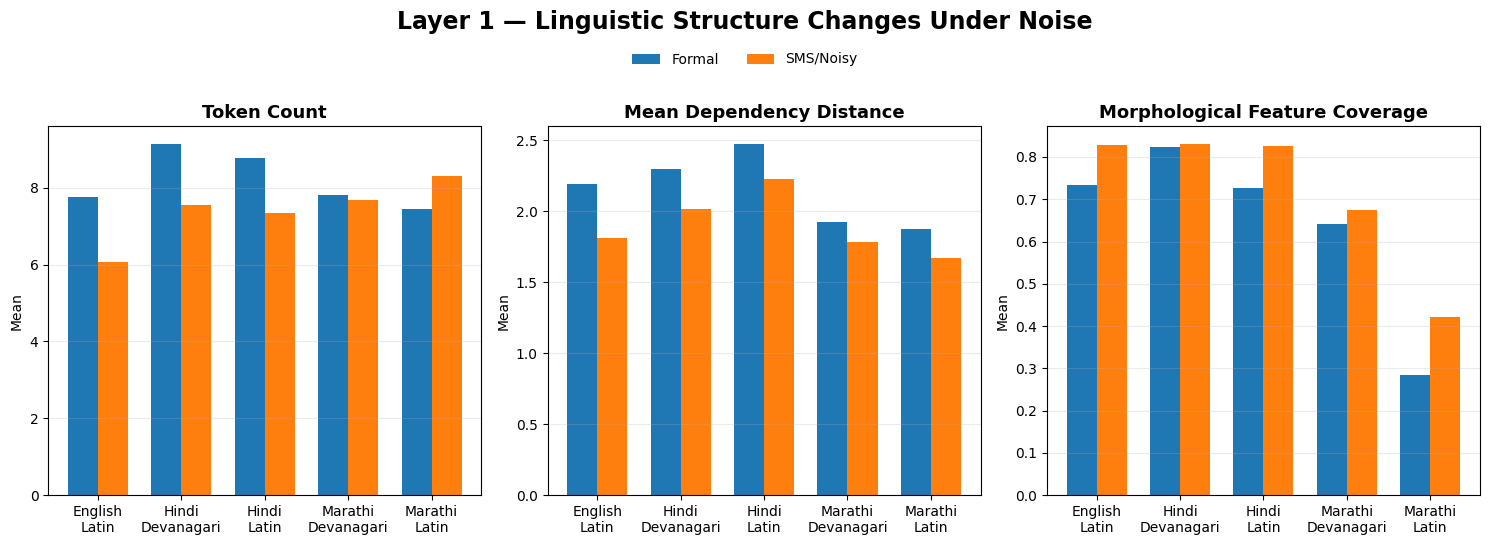

✓ FIGURE 1 CREATED

Saved to:
/content/drive/MyDrive/NLP_Poster_Project/poster_figures/Figure_1_Layer1_Linguistic_Changes.png


In [ ]:
# ============================================================
# FIGURE 1 — LAYER 1: LINGUISTIC CHANGES
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Ensure output directory exists
# ------------------------------------------------------------

FIGURE_DIR = os.path.join(
    PROJECT_DIR,
    "poster_figures"
)

os.makedirs(FIGURE_DIR, exist_ok=True)

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------

metrics = [
    "token_count",
    "mean_dependency_distance",
    "morph_feature_coverage"
]

metric_labels = {
    "token_count": "Token Count",
    "mean_dependency_distance": "Mean Dependency Distance",
    "morph_feature_coverage": "Morphological Feature Coverage"
}

plot_df = (
    layer1_results
    .groupby(
        ["language", "script", "noise_level"]
    )[metrics]
    .mean()
    .reset_index()
)

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

conditions = [
    ("English", "Latin"),
    ("Hindi", "Devanagari"),
    ("Hindi", "Latin"),
    ("Marathi", "Devanagari"),
    ("Marathi", "Latin")
]

for ax, metric in zip(axes, metrics):

    # Pivot to Formal / Noisy
    temp = plot_df.pivot_table(
        index=["language", "script"],
        columns="noise_level",
        values=metric
    ).reset_index()

    x = range(len(temp))

    ax.bar(
        [i - 0.18 for i in x],
        temp["Formal"],
        width=0.36,
        label="Formal"
    )

    ax.bar(
        [i + 0.18 for i in x],
        temp["SMS/Noisy"],
        width=0.36,
        label="SMS/Noisy"
    )

    labels = [
        f"{lang}\n{script}"
        for lang, script
        in zip(temp["language"], temp["script"])
    ]

    ax.set_xticks(list(x))
    ax.set_xticklabels(
        labels,
        rotation=0
    )

    ax.set_title(
        metric_labels[metric],
        fontsize=13,
        fontweight="bold"
    )

    ax.set_ylabel("Mean")

    ax.grid(
        axis="y",
        alpha=0.25
    )

# ------------------------------------------------------------
# Shared legend
# ------------------------------------------------------------

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

fig.suptitle(
    "Layer 1 — Linguistic Structure Changes Under Noise",
    fontsize=17,
    fontweight="bold",
    y=1.08
)

plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

figure_path = os.path.join(
    FIGURE_DIR,
    "Figure_1_Layer1_Linguistic_Changes.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 70)
print("✓ FIGURE 1 CREATED")
print("=" * 70)
print("\nSaved to:")
print(figure_path)

LAYER 2 — FIGURE DATA CHECK


,effect,layer,mean_distance,std_distance,n
0,Noise Shift,2,0.053158,0.021846,250
1,Noise Shift,6,0.050140,0.019243,250
2,Noise Shift,12,0.004371,0.001976,250
3,Script Shift,2,0.099039,0.024154,200
4,Script Shift,6,0.078045,0.021162,200
5,Script Shift,12,0.008040,0.002107,200



Expected n = 50 per effect × layer

Sample sizes: [250, 250, 250, 200, 200, 200]


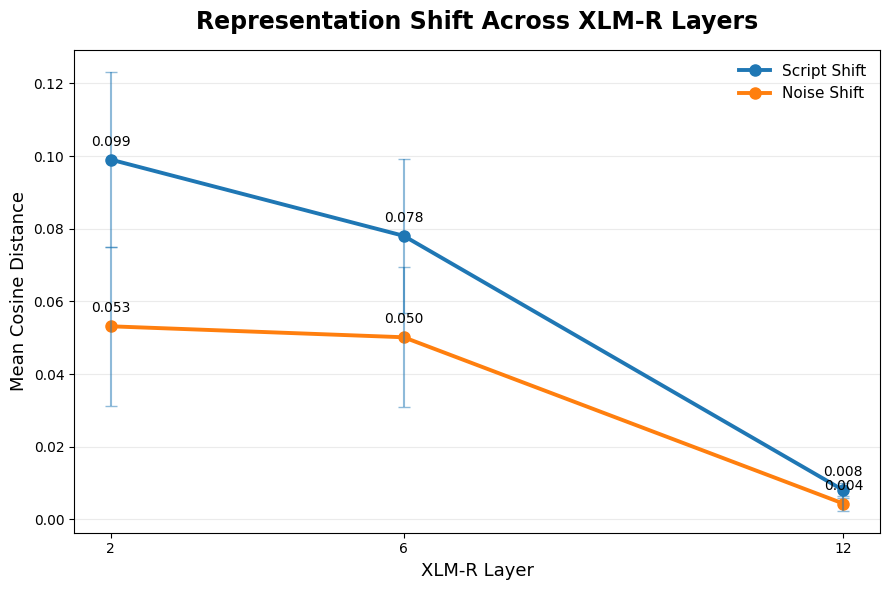


✓ FIGURE 2 CREATED SUCCESSFULLY

Saved to:
/content/drive/MyDrive/NLP_Poster_Project/poster_figures/Figure_2_Layer2_Representation_Shift.png


In [ ]:
# ============================================================
# FIGURE 2 — LAYER 2: REPRESENTATION SHIFT ACROSS MODEL DEPTH
# FINAL CORRECTED VERSION
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

LAYER2_DIR = os.path.join(
    PROJECT_DIR,
    "layer2_analysis"
)

FIGURE_DIR = os.path.join(
    PROJECT_DIR,
    "poster_figures"
)

os.makedirs(FIGURE_DIR, exist_ok=True)

# ------------------------------------------------------------
# Load the actual Layer 2 pairwise results
# ------------------------------------------------------------

layer2 = pd.read_csv(
    os.path.join(
        LAYER2_DIR,
        "layer2_pairwise_results.csv"
    )
)

# ------------------------------------------------------------
# Map actual comparison labels to poster labels
# ------------------------------------------------------------

effect_map = {
    "Native_vs_Romanized": "Script Shift",
    "Formal_vs_Noisy": "Noise Shift"
}

layer2["effect"] = layer2["comparison"].map(effect_map)

# Keep only the two main effects
plot_df = layer2[
    layer2["effect"].notna()
].copy()

# ------------------------------------------------------------
# Aggregate across the 50 core items
# ------------------------------------------------------------

summary = (
    plot_df
    .groupby(
        ["effect", "layer"]
    )
    .agg(
        mean_distance=("distance", "mean"),
        std_distance=("distance", "std"),
        n=("distance", "count")
    )
    .reset_index()
)

summary = summary.sort_values(
    ["effect", "layer"]
)

# ------------------------------------------------------------
# Verify expected sample sizes
# ------------------------------------------------------------

print("=" * 70)
print("LAYER 2 — FIGURE DATA CHECK")
print("=" * 70)

display(
    summary.round(6)
)

print("\nExpected n = 50 per effect × layer")

print(
    "\nSample sizes:",
    summary["n"].tolist()
)

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 6)
)

for effect in [
    "Script Shift",
    "Noise Shift"
]:

    subset = summary[
        summary["effect"] == effect
    ].sort_values("layer")

    ax.plot(
        subset["layer"],
        subset["mean_distance"],
        marker="o",
        linewidth=2.8,
        markersize=8,
        label=effect
    )

    # Error bars = ± SD
    ax.errorbar(
        subset["layer"],
        subset["mean_distance"],
        yerr=subset["std_distance"],
        fmt="none",
        capsize=4,
        alpha=0.5
    )

    # Numerical labels
    for _, row in subset.iterrows():

        ax.annotate(
            f"{row['mean_distance']:.3f}",
            (
                row["layer"],
                row["mean_distance"]
            ),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center",
            fontsize=10
        )

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.set_title(
    "Representation Shift Across XLM-R Layers",
    fontsize=17,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "XLM-R Layer",
    fontsize=13
)

ax.set_ylabel(
    "Mean Cosine Distance",
    fontsize=13
)

ax.set_xticks(
    [2, 6, 12]
)

ax.set_xlim(
    1.5,
    12.5
)

ax.legend(
    frameon=False,
    fontsize=11
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

figure_path = os.path.join(
    FIGURE_DIR,
    "Figure_2_Layer2_Representation_Shift.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n" + "=" * 70)
print("✓ FIGURE 2 CREATED SUCCESSFULLY")
print("=" * 70)

print("\nSaved to:")
print(figure_path)

LAYER 3 — POSTER DATA

Language/effect columns:
['language', 'effect', 'layer', 'n', 'mean', 'std']

Shape:
(15, 6)

Category ranking:


,category,overall_mean_shift
0,Ambiguous System Term,0.056828
1,Occupational / Morphosyntactic Gender,0.049587
2,Cultural Ambiguity,0.048490
3,Missing Context,0.048308
4,Unknown / Pseudo Entity,0.040782



Script Shift data:


,language,effect,layer,n,mean,std
6,Hindi,Script Shift,2,100,0.090713,0.022342
7,Hindi,Script Shift,6,100,0.069966,0.021475
8,Hindi,Script Shift,12,100,0.007510,0.002201
12,Marathi,Script Shift,2,100,0.107366,0.023099
13,Marathi,Script Shift,6,100,0.086124,0.017526
14,Marathi,Script Shift,12,100,0.008570,0.001875



Noise Shift data:


,language,effect,layer,n,mean,std
0,English,Noise Shift,2,50,0.040311,0.018994
1,English,Noise Shift,6,50,0.051884,0.018594
2,English,Noise Shift,12,50,0.004593,0.001799
3,Hindi,Noise Shift,2,100,0.054798,0.022638
4,Hindi,Noise Shift,6,100,0.050607,0.021269
5,Hindi,Noise Shift,12,100,0.004256,0.002161
9,Marathi,Noise Shift,2,100,0.057942,0.020002
10,Marathi,Noise Shift,6,100,0.048800,0.017444
11,Marathi,Noise Shift,12,100,0.004375,0.001873


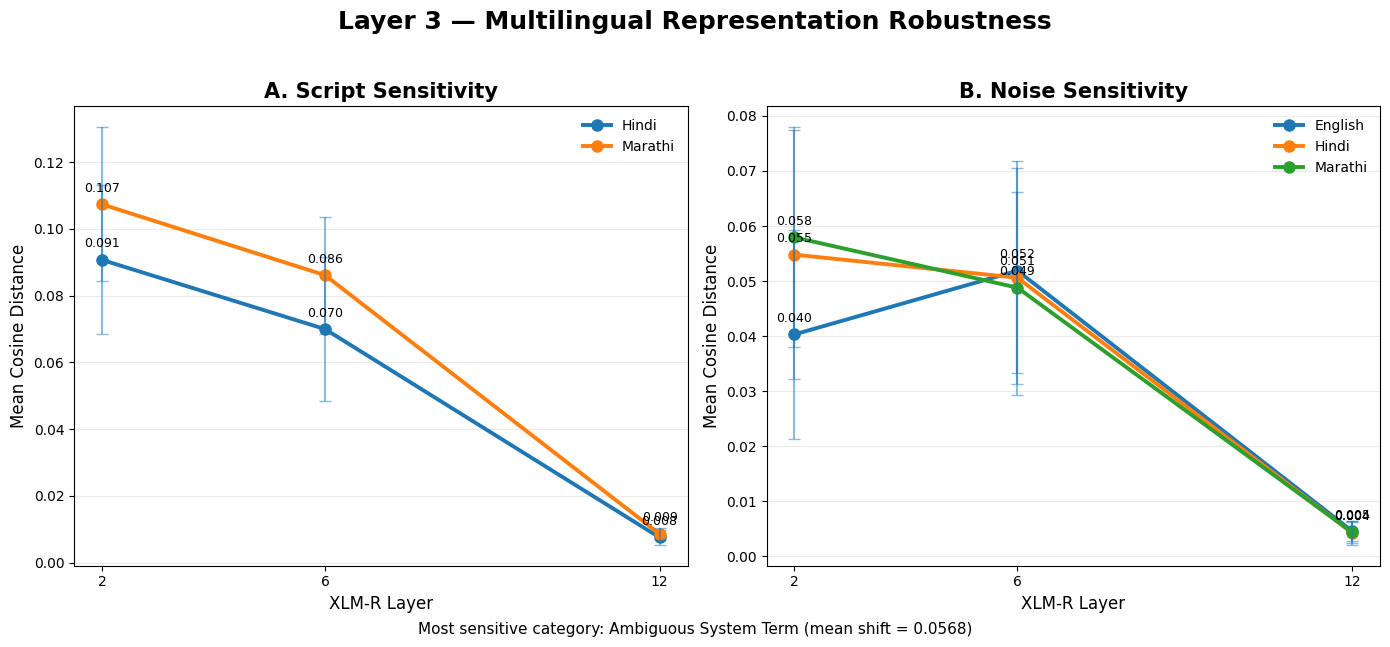


✓ FIGURE 3 CREATED SUCCESSFULLY

Saved to:
/content/drive/MyDrive/NLP_Poster_Project/poster_figures/Figure_3_Layer3_Multilingual_Robustness.png


In [ ]:
# ============================================================
# FIGURE 3 — LAYER 3: MULTILINGUAL ROBUSTNESS
# FINAL CORRECTED VERSION
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

FIGURE_DIR = os.path.join(
    PROJECT_DIR,
    "poster_figures"
)

POSTER_DIR = os.path.join(
    PROJECT_DIR,
    "poster_results"
)

os.makedirs(FIGURE_DIR, exist_ok=True)

# ------------------------------------------------------------
# Load saved Layer 3 poster data
# ------------------------------------------------------------

language_effects = pd.read_csv(
    os.path.join(
        POSTER_DIR,
        "poster_layer3_language_effects.csv"
    )
)

category_ranking = pd.read_csv(
    os.path.join(
        POSTER_DIR,
        "poster_layer3_category_ranking.csv"
    )
)

script_noise_stats = pd.read_csv(
    os.path.join(
        POSTER_DIR,
        "poster_layer3_script_vs_noise.csv"
    )
)

# ------------------------------------------------------------
# Check data
# ------------------------------------------------------------

print("=" * 70)
print("LAYER 3 — POSTER DATA")
print("=" * 70)

print("\nLanguage/effect columns:")
print(language_effects.columns.tolist())

print("\nShape:")
print(language_effects.shape)

print("\nCategory ranking:")
display(category_ranking)

# ------------------------------------------------------------
# Split effects
# ------------------------------------------------------------

script_df = language_effects[
    language_effects["effect"] == "Script Shift"
].copy()

noise_df = language_effects[
    language_effects["effect"] == "Noise Shift"
].copy()

print("\nScript Shift data:")
display(script_df)

print("\nNoise Shift data:")
display(noise_df)

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

# ============================================================
# PANEL A — SCRIPT SHIFT
# ============================================================

ax = axes[0]

for language in ["Hindi", "Marathi"]:

    subset = script_df[
        script_df["language"] == language
    ].sort_values("layer")

    ax.plot(
        subset["layer"],
        subset["mean"],
        marker="o",
        linewidth=2.8,
        markersize=8,
        label=language
    )

    ax.errorbar(
        subset["layer"],
        subset["mean"],
        yerr=subset["std"],
        fmt="none",
        capsize=4,
        alpha=0.5
    )

    for _, row in subset.iterrows():

        ax.annotate(
            f"{row['mean']:.3f}",
            (
                row["layer"],
                row["mean"]
            ),
            xytext=(0, 9),
            textcoords="offset points",
            ha="center",
            fontsize=9
        )

ax.set_title(
    "A. Script Sensitivity",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "XLM-R Layer",
    fontsize=12
)

ax.set_ylabel(
    "Mean Cosine Distance",
    fontsize=12
)

ax.set_xticks([2, 6, 12])

ax.set_xlim(1.5, 12.5)

ax.legend(
    frameon=False
)

ax.grid(
    axis="y",
    alpha=0.25
)

# ============================================================
# PANEL B — NOISE SHIFT
# ============================================================

ax = axes[1]

for language in ["English", "Hindi", "Marathi"]:

    subset = noise_df[
        noise_df["language"] == language
    ].sort_values("layer")

    ax.plot(
        subset["layer"],
        subset["mean"],
        marker="o",
        linewidth=2.8,
        markersize=8,
        label=language
    )

    ax.errorbar(
        subset["layer"],
        subset["mean"],
        yerr=subset["std"],
        fmt="none",
        capsize=4,
        alpha=0.5
    )

    for _, row in subset.iterrows():

        ax.annotate(
            f"{row['mean']:.3f}",
            (
                row["layer"],
                row["mean"]
            ),
            xytext=(0, 9),
            textcoords="offset points",
            ha="center",
            fontsize=9
        )

ax.set_title(
    "B. Noise Sensitivity",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "XLM-R Layer",
    fontsize=12
)

ax.set_ylabel(
    "Mean Cosine Distance",
    fontsize=12
)

ax.set_xticks([2, 6, 12])

ax.set_xlim(1.5, 12.5)

ax.legend(
    frameon=False
)

ax.grid(
    axis="y",
    alpha=0.25
)

# ------------------------------------------------------------
# Main title
# ------------------------------------------------------------

fig.suptitle(
    "Layer 3 — Multilingual Representation Robustness",
    fontsize=18,
    fontweight="bold",
    y=1.03
)

# ------------------------------------------------------------
# Category annotation
# ------------------------------------------------------------

top_category = category_ranking.iloc[0]

fig.text(
    0.5,
    -0.01,
    (
        f"Most sensitive category: "
        f"{top_category['category']} "
        f"(mean shift = {top_category['overall_mean_shift']:.4f})"
    ),
    ha="center",
    fontsize=11
)

plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

figure_path = os.path.join(
    FIGURE_DIR,
    "Figure_3_Layer3_Multilingual_Robustness.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n" + "=" * 70)
print("✓ FIGURE 3 CREATED SUCCESSFULLY")
print("=" * 70)

print("\nSaved to:")
print(figure_path)